<div style="border: 3px solid #1f6fb2; border-radius: 10px; padding: 52px 44px; text-align: center; background: linear-gradient(160deg, #f8fbff 0%, #e4f0fc 100%); margin-bottom: 8px;">
  <div style="font-size: 56px; font-weight: 900; color: #1f6fb2; letter-spacing: 4px; margin-bottom: 18px; font-family: sans-serif;">
    ICU SEPSIS RL
  </div>
  <div style="font-size: 20px; font-weight: 700; color: #1a3a5c; margin-bottom: 8px;">
    Clinical Treatment Optimisation: Sepsis ICU Management
  </div>
  <div style="font-size: 15px; font-style: italic; color: #4a6a8a; margin-bottom: 38px;">
    Configuration B – Deep Reinforcement Learning
  </div>
  <hr style="border: none; border-top: 2px solid #1f6fb2; width: 48%; margin: 0 auto 28px auto;">
  <div style="font-size: 14px; font-weight: 600; color: #1a3a5c; margin-bottom: 6px;">
    Ana Gonçalves &nbsp;|&nbsp; Catarina &nbsp;|&nbsp; Filipa São João &nbsp;|&nbsp; Inês Esteves &nbsp;|&nbsp; Maria
  </div>
  <div style="font-size: 13px; font-style: italic; color: #6a8aaa;">
    NOVA IMS – Master in Data Science &amp; Advanced Analytics - Reinforcement Learning - May 2026
  </div>
</div>


<font color='#2f94d7' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a>

- [1. Project Overview](#1)
- [2. Set Up & Import Libraries](#2)
- [3. Environment Exploration](#3)
  - [3.1 Observation Space - 47 Physiological Features](#3_1)
  - [3.2 Random Baseline - Base Environment](#3_2)
  - [3.3 Random Baseline - Clinical Environment (Wrappers)](#3_3)
  - [3.4 Environment Comparison (Base vs Clinical)](#3_4)
  - [3.5 Feature Outcome Relationship](#3_5)
  - [3.6 Action Space — Treatment Intensity](#3_6)
- [4. DQN (Deep Q-Network)](#4)
  - [4.1 DQN - Rationale & Architecture](#4_1)
  - [4.2 DQN - Training (Run 1)](#4_2)
  - [4.3 DQN - Hyperparameter Tuning (Optuna)](#4_3)
  - [4.4 Double DQN - Extended Training Run](#4_4)
- [5. PPO (Proximal Policy Optimization)](#5)
  - [5.1 PPO - Rationale & Architecture](#5_1)
  - [5.2 PPO - Training (Run 1)](#5_2)
  - [5.3 PPO - Hyperparameter Tuning (Optuna)](#5_3)
- [6. Creative Extension](#6)
  - [6.1 Ablation Study](#6_1)
  - [6.2 SHAP (SHapley Additive exPlanations)](#6_2)

  


# <font color='#2f94d7' size=6>**1. Project Overview - Config B**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

In Config A, patient state was represented as a discrete integer produced by discretising a set of clinical measurements into a small number of categories. **Config B uses the full ICU-Sepsis environment**, also built from MIMIC-III data, but with two fundamental changes that make the problem substantially harder.

**Change 1 — Continuous observations.**
The agent now receives a **47-dimensional continuous feature vector** instead of a single discrete index. This vector contains the actual normalised physiological measurements used in the original Komorowski et al. (2018) AI Clinician study, including SOFA score, heart rate, lactate, blood pressure, creatinine, and 42 other clinical variables.

With continuous observations, a tabular Q-table is no longer feasible: it would require one entry per unique float vector, making it effectively infinite.

**Change 2 — Clinical reality wrappers.**
Config B injects three orthogonal failure modes that reflect challenges faced by real clinical AI deployments.

The first wrapper, `EpisodicNoisyObsEnv`, models episodic monitor malfunction. When active, the observations received by the agent are corrupted by noise for the entire episode, testing robustness to measurement error.

The second wrapper, `EpisodicMissingObsEnv`, models situations where lab results are unavailable for a full episode. This tests how well the agent handles partial observability.

The third wrapper, `AcuteEventEnv`, introduces rare, sudden patient deterioration events such as cardiac arrest or acute organ failure. These occur independently of any treatment decision and represent irreducible stochasticity in the environment.


Key environment properties for Config B:
- **Actions**: 25 total (5 vasopressor levels × 5 IV fluid dose levels)
- **Reward**: +1.0 at survival, 0.0 at death, plus a small treatment intensity penalty (lam = 0.02)
- **Observation**: `Box(47,)`, a normalised physiological feature vector, potentially noisy or incomplete

# <font color='#2f94d7' size=6>**2. Set Up & Import Libraries**</font> <a class="anchor" id="2"></a>

[Back to TOC](#toc)

In [1]:
# Install dependencies (run once)
# !pip install icu-sepsis numpy pandas matplotlib seaborn optuna

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
import os
import sys
import gymnasium as gym
import random
import time
import itertools

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical
from collections import deque
import optuna
from optuna.samplers import TPESampler
from optuna.pruners  import MedianPruner

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

warnings.filterwarnings('ignore')

# Project modules
from envs.env_setup import (
    ENV_ID, N_STATES, N_ACTIONS, STATE_SURVIVED, STATE_DIED,
    GAMMA, INTENSITY, SOFA_BIAS, LAM,
    make_sepsis_env,
)
from envs.continuous_sepsis_env import ContinuousICUSepsisEnv, FEATURE_NAMES
from envs.wrappers import (
    EpisodicNoisyObsEnv, EpisodicMissingObsEnv,
    AcuteEventEnv, make_clinical_env
)

# Import everything from algorithms and utils
from src.dqn_sac_functions import *
from src.utils import *
from src.ppo_functions import *
from src.creative_extension import *


# Config B constants
OBS_DIM = 47

# Plotting style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

print(f'ICU-Sepsis-v2 | States: {N_STATES} | Actions: {N_ACTIONS}')
print(f'Terminal states: {STATE_SURVIVED} (survived, r=+1)  {STATE_DIED} (died, r=0)')
print('Setup complete!')

Device: cpu


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


ICU-Sepsis-v2 | States: 716 | Actions: 25
Terminal states: 714 (survived, r=+1)  713 (died, r=0)
Setup complete!


In [2]:
# Config B observation constants
OBS_DIM  = 47   # 47 physiological features

In [3]:
# Verify wrapper stack order
test_env = make_clinical_env()
e = test_env
layers = []
while hasattr(e, 'env'):
    layers.append(type(e).__name__)
    e = e.env
layers.append(type(e).__name__)
test_env.close()


print()
print('Clinical environment wrapper stack (outer → inner):')
for i, layer in enumerate(layers):
    prefix = '  ' * i + ('└─ ' if i > 0 else '┌─ ')
    print(f'{prefix}{layer}')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

Clinical environment wrapper stack (outer → inner):
┌─ AcuteEventEnv
  └─ EpisodicMissingObsEnv
    └─ EpisodicNoisyObsEnv
      └─ ContinuousICUSepsisEnv


In [4]:
# REPRODUCIBILITY
SEED      = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

# <font color='#2f94d7' size=6>**3. Environment Exploration**</font> <a class="anchor" id="3"></a>

[Back to TOC](#toc)

## <font color='#2f94d7' size=6>**3.1 Observation Space - 47 Physiological Features**</font> <a class="anchor" id="3_1"></a>

[Back to TOC](#toc)

The cluster centres of the 714 non-terminal states are extracted directly from the environment. Each row is a normalised physiological feature vector that the agent observes.

In [21]:
# Build the base continuous env and extract cluster centres
base_env = ContinuousICUSepsisEnv(params=make_sepsis_env())

# Shape: (716, 47).  Rows 714 and 715 are terminal states — drop them.
all_centers = base_env._cluster_centers          # (716, 47)
clinical_centers = all_centers[:714]             # (714, 47) — non-terminal only

df_states = pd.DataFrame(clinical_centers, columns=FEATURE_NAMES)

print()
print(f'Clinical state matrix shape : {clinical_centers.shape}')
print('Summary statistics (first 8 features):')
df_states.describe().T.head(8).round(3)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

Clinical state matrix shape : (714, 47)
Summary statistics (first 8 features):


,count,mean,std,min,25%,50%,75%,max
Albumin,714.0,-0.061,0.125,-0.479,-0.148,-0.060,0.022,0.327
ALP,714.0,-0.134,0.289,-0.500,-0.373,-0.225,0.079,0.500
ALT,714.0,-0.425,0.213,-0.500,-0.496,-0.479,-0.434,3.722
AST,714.0,0.449,0.165,0.000,0.335,0.426,0.538,1.100
Bilirubin,714.0,-0.020,0.579,-2.166,-0.355,0.068,0.412,1.094
BUN,714.0,0.034,0.629,-0.825,-0.263,-0.068,0.140,5.403
Chloride,714.0,-0.055,0.746,-2.521,-0.224,0.256,0.436,0.672
Creatinine,714.0,0.064,0.695,-1.276,-0.495,-0.044,0.578,2.221


The base environment exposes a (714, 47) matrix of cluster centres,
one centroid per non-terminal clinical state, with 47 physiological
features each (the same variables used in Komorowski et al. 2018).

**Key observations:**
- All 714 states have complete feature vectors (no missing values in
  the state representation itself)
- Features are approximately centred at 0, confirming normalisation, so
  no additional preprocessing is needed before feeding observations to
  a neural network
- Some features show high maximum values (e.g. BUN, ALT), reflecting
  clusters of patients in critical condition, expected in an ICU setting

The 714 × 47 continuous state space makes tabular methods infeasible,
motivating the use of function approximation in Config B.

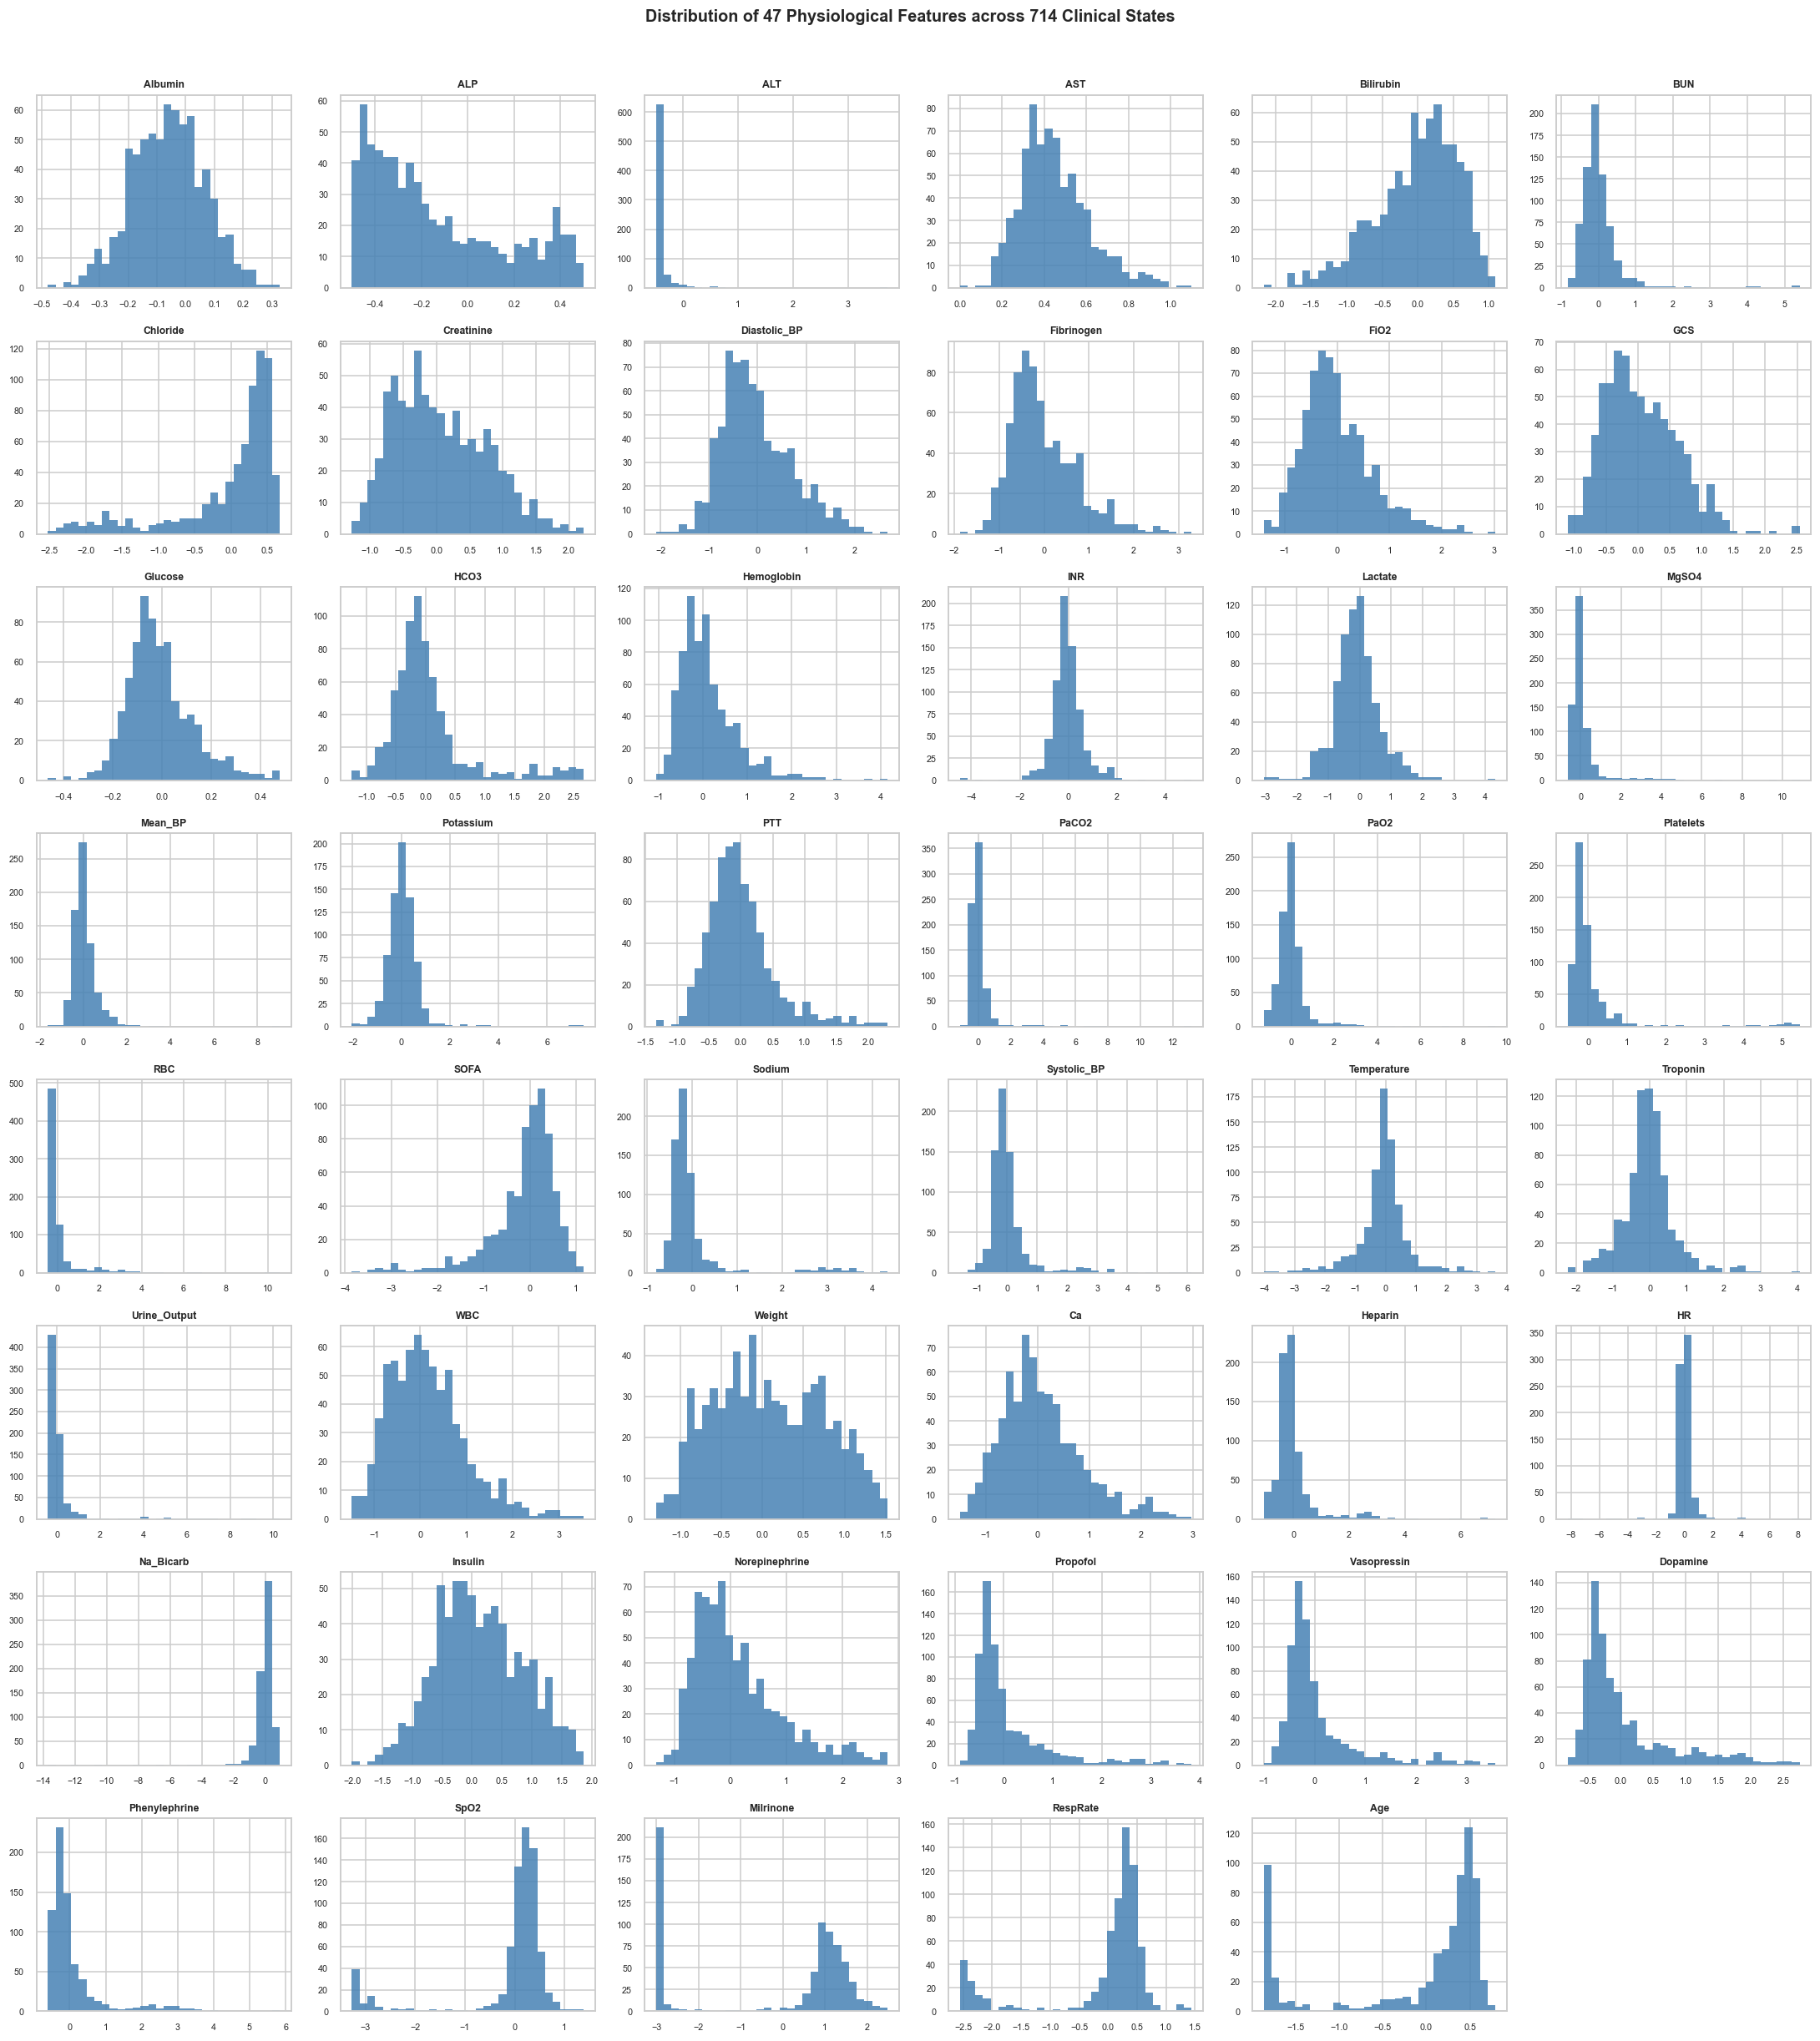

In [22]:
# Distribution of all 47 features across states
fig, axes = plt.subplots(8, 6, figsize=(20, 22))
axes = axes.flatten()

for i, feat in enumerate(FEATURE_NAMES):
    ax = axes[i]
    ax.hist(df_states[feat], bins=30, color='steelblue', edgecolor='none', alpha=0.85)
    ax.set_title(feat, fontsize=8, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(labelsize=7)

# hide spare axes (47 features, 48 subplots)
for j in range(len(FEATURE_NAMES), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribution of 47 Physiological Features across 714 Clinical States',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The 47 physiological features show a lot of right-skewed distributions typical
of ICU data, most patients cluster around normal values, with a minority
in critical states driving extreme observations. Several treatment-related
features (e.g. Milrinone, Vasopressin, Norepinephrine) are zero for most
states, reflecting that aggressive interventions are used selectively.

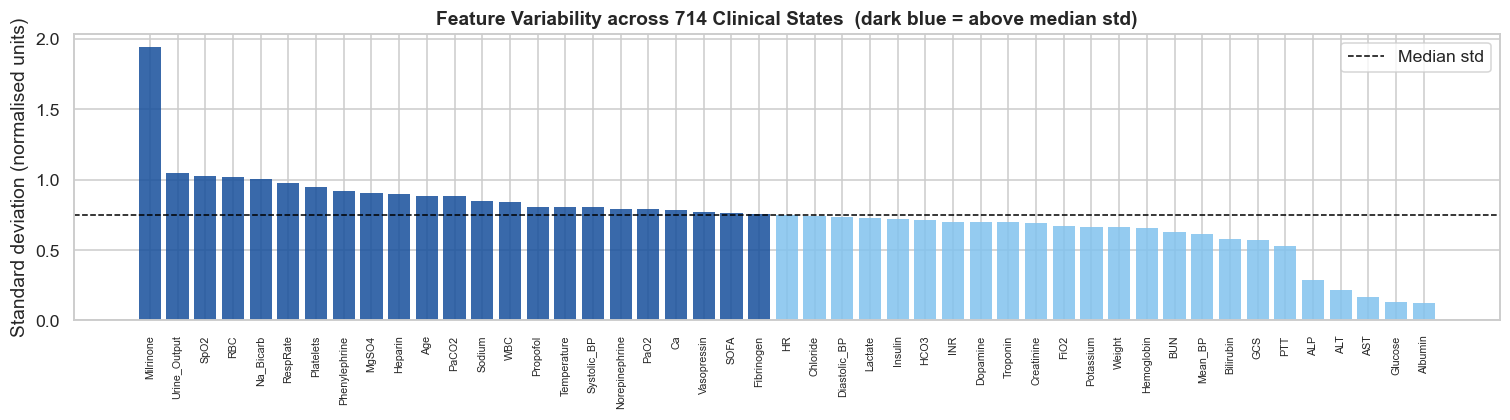

In [23]:
# Feature variance ranking
feat_std = df_states.std().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 4))
colors = ["#164f9b" if s > feat_std.median() else "#81c2ee" for s in feat_std]
ax.bar(feat_std.index, feat_std.values, color=colors, edgecolor='none', alpha=0.85)
ax.set_xticks(range(len(feat_std)))
ax.set_xticklabels(feat_std.index, rotation=90, fontsize=7)
ax.set_ylabel('Standard deviation (normalised units)')
ax.set_title('Feature Variability across 714 Clinical States  '
             '(dark blue = above median std)', fontweight='bold')
ax.axhline(feat_std.median(), color='black', ls='--', lw=1, label='Median std')
ax.legend()
plt.tight_layout()
plt.show()

Features vary substantially in how much they differ across the 714 clinical
states. High-variability features (e.g. Milrinone, Urine_Output, SpO2,
RBC) are more discriminative between states (red bars), while low-variability features
(e.g. Albumin, Glucose, AST) contribute less to distinguishing clinical
conditions (blue bars). This suggests the observation space contains redundancy,
not all 47 features carry equal information for the agent.

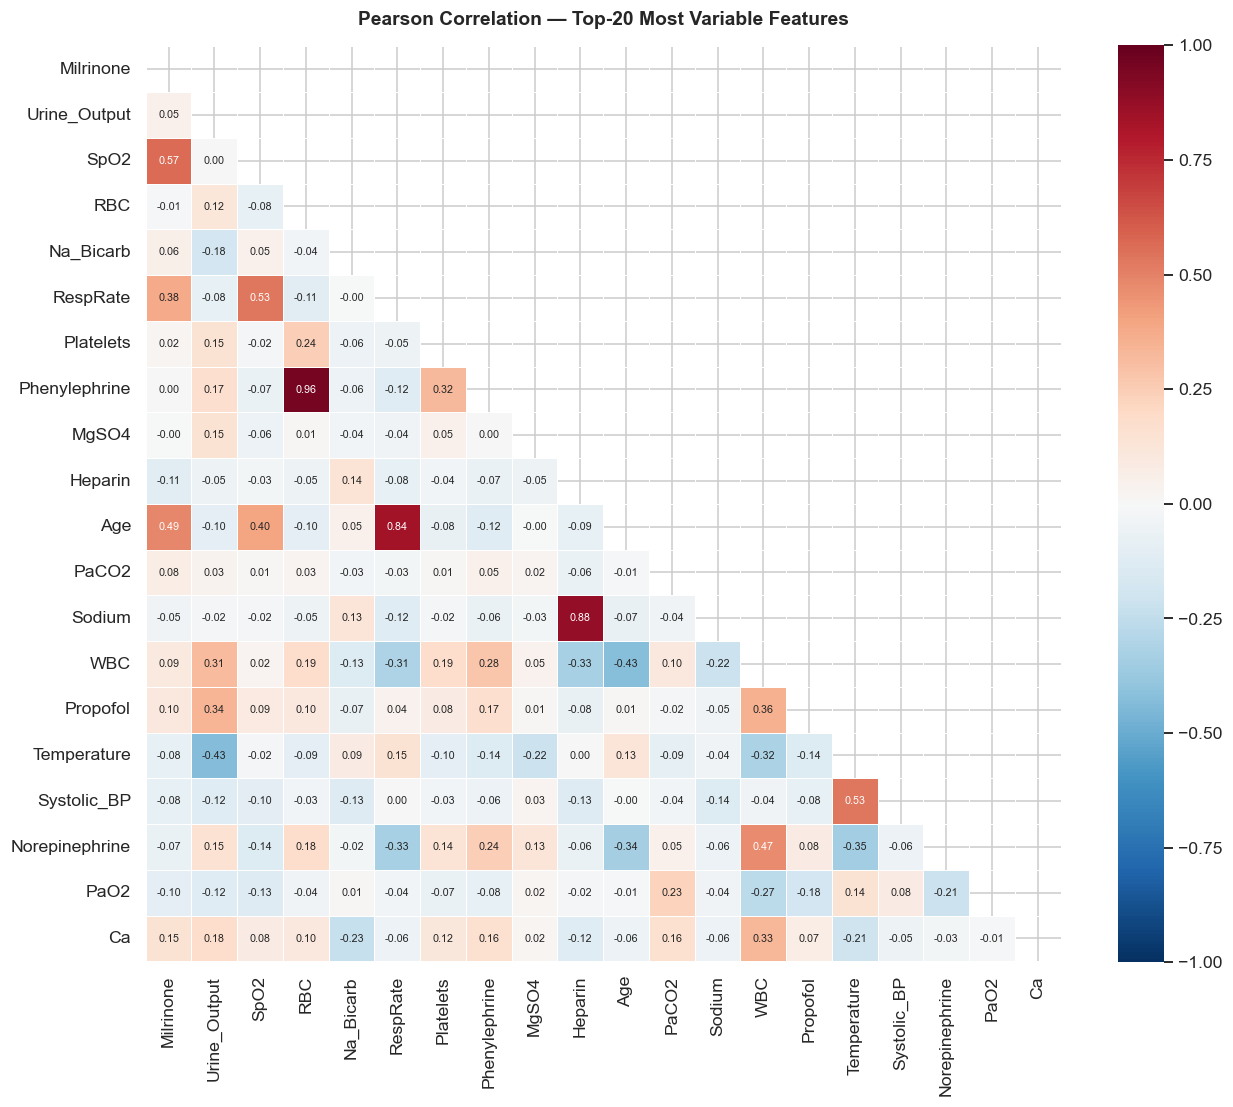

In [24]:
# Correlation heatmap (top-20 most variable features)
top20 = feat_std.head(20).index.tolist()
corr  = df_states[top20].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, cmap='RdBu_r', center=0,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    square=True, linewidths=0.4, ax=ax,
    vmin=-1, vmax=1
)
ax.set_title('Pearson Correlation — Top-20 Most Variable Features',
             fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

Most feature pairs are weakly correlated, meaning the observation vector
carries largely complementary information. However, three pairs show
notably high correlation:
- **RBC - Phenylephrine (r=0.96)** — near-redundant features
- **Sodium - Heparin (r=0.88)** — strong association between
  electrolyte levels and anticoagulation treatment
- **Age - RespRate (r=0.84)** — older patients tend to present higher
  respiratory rates, reflecting reduced physiological reserve

These correlations are unlikely to cause problems for a neural network
but are worth noting as sources of redundancy in the input space.

## <font color='#2f94d7' size=6>**3.2 Random Baseline - Base Environment**</font> <a class="anchor" id="3_2"></a>

[Back to TOC](#toc)

We roll out `N_EPISODES = 1000` episodes using a uniformly random policy to characterise baseline episode length, survival rate, and reward distribution **before any learning**.


> **Note:** results vary slightly between runs as each episode is initialised
> with a different random seed. Values reported reflect typical observed ranges.

In [25]:
# Random-policy rollouts on the clean base env

N_EPISODES = 1000   # episodes for random-policy rollouts

print('Rolling out random policy on clean base env:')
records_clean = rollout(base_env, N_EPISODES)
df_ep = pd.DataFrame([{k: v for k, v in r.items() if k != 'obs_traj'}
                       for r in records_clean])

survival_rate = df_ep['survived'].mean()
mean_length   = df_ep['length'].mean()
print(f'Random policy  |  Survival rate: {survival_rate:.1%}  '
      f'|  Mean episode length: {mean_length:.1f} steps')

Rolling out random policy on clean base env:
Random policy  |  Survival rate: 73.6%  |  Mean episode length: 10.1 steps


With this results it's possible to understand that each episode simulates a sequence of ~10 treatment decisions (vasopressor + IV fluid dose). Any trained agent must exceed the survival rate recorded
here to demonstrate meaningful learning.

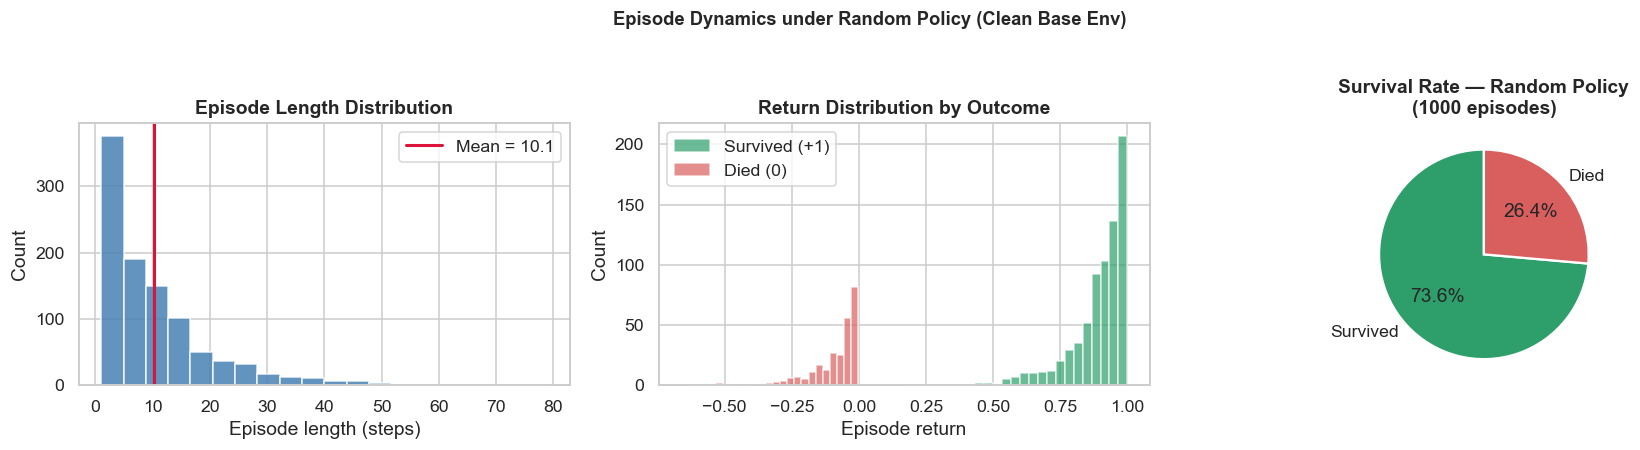

In [26]:
# Episode length & return distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Episode length
axes[0].hist(df_ep['length'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(mean_length, color='crimson', lw=2, label=f'Mean = {mean_length:.1f}')
axes[0].set_xlabel('Episode length (steps)')
axes[0].set_ylabel('Count')
axes[0].set_title('Episode Length Distribution', fontweight='bold')
axes[0].legend()

# Return distribution
survived_col = df_ep['survived'].map({True: 'Survived (+1)', False: 'Died (0)'})
for outcome, colour in [('Survived (+1)', '#2E9E6B'), ('Died (0)', '#D95F5F')]:
    mask = survived_col == outcome
    axes[1].hist(df_ep.loc[mask, 'return'], bins=25,
                 label=outcome, color=colour, alpha=0.7, edgecolor='white')
axes[1].set_xlabel('Episode return')
axes[1].set_ylabel('Count')
axes[1].set_title('Return Distribution by Outcome', fontweight='bold')
axes[1].legend()

# Survival pie
counts = df_ep['survived'].value_counts()
axes[2].pie(
    [counts.get(True, 0), counts.get(False, 0)],
    labels=['Survived', 'Died'],
    colors=["#2E9E6B", "#D95F5F"],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[2].set_title(f'Survival Rate — Random Policy\n({N_EPISODES} episodes)',
                  fontweight='bold')

plt.suptitle('Episode Dynamics under Random Policy (Clean Base Env)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Episode length:** is right-skewed, most episodes resolve in fewer than 10
steps, though a long tail exists where patients take much longer to stabilise
or deteriorate. The mean episode length is ~10 steps.

**Return distribution by Outcome:** shows two clear clusters: episodes ending in death
concentrate near 0, while survival episodes cluster close to 1.0 but rarely
reach it exactly, the treatment intensity penalty (lam=0.02) accumulates
across steps and slightly reduces the final return even in survived episodes.

**Survival rate: ~72%** under a random policy on the clean environment.
This is the performance floor for the base environment — trained agents
must exceed this to demonstrate meaningful learning.

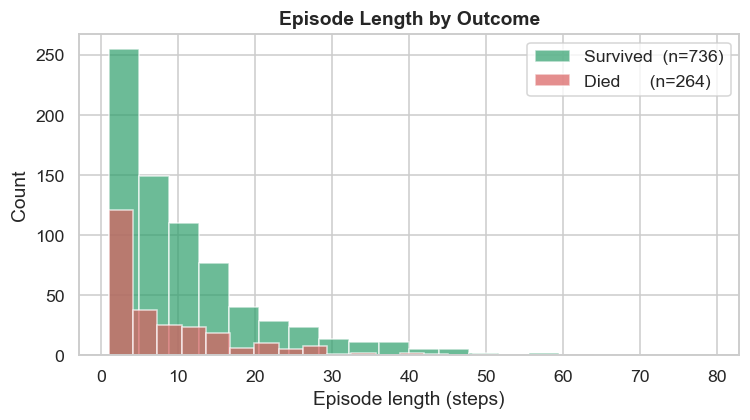

Survived — mean length: 10.62  std: 10.39
Died     — mean length: 8.81  std: 9.23


In [27]:
# Episode length by outcome
fig, ax = plt.subplots(figsize=(7, 4))
survived_lengths = df_ep.loc[df_ep['survived'],  'length']
died_lengths     = df_ep.loc[~df_ep['survived'], 'length']

ax.hist(survived_lengths, bins=20, alpha=0.7, color="#2E9E6B",
        label=f'Survived  (n={len(survived_lengths)})', edgecolor='white')
ax.hist(died_lengths,     bins=20, alpha=0.7, color="#D95F5F",
        label=f'Died      (n={len(died_lengths)})',     edgecolor='white')
ax.set_xlabel('Episode length (steps)')
ax.set_ylabel('Count')
ax.set_title('Episode Length by Outcome', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Survived — mean length: {survived_lengths.mean():.2f}  '
      f'std: {survived_lengths.std():.2f}')
print(f'Died     — mean length: {died_lengths.mean():.2f}  '
      f'std: {died_lengths.std():.2f}')

Survived and died episodes show nearly identical length distributions
(survived: mean ~10.5 steps, died: mean ~9.9 steps), with high variability
in both groups (std ~ 10).

This confirms that under a random policy, episode length is not predictive
of outcome, a patient can die quickly or after many steps regardless of
how many treatment decisions were made. What matters is the **quality** of
those decisions, not the quantity.

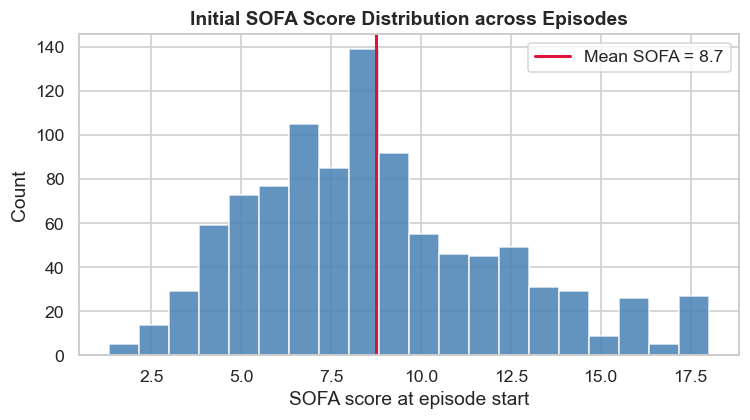

Mean SOFA : 8.75
Std SOFA  : 3.49
Min SOFA  : 1
Max SOFA  : 18


In [28]:
# SOFA score distribution at episode start
sofa_scores = []
rng_sofa = np.random.default_rng(SEED)
for i in range(N_EPISODES):
    _, info = base_env.reset(seed=int(rng_sofa.integers(1_000_000)))
    sofa_scores.append(info['sofa_score'])

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(sofa_scores, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(sofa_scores), color='crimson', lw=2,
           label=f'Mean SOFA = {np.mean(sofa_scores):.1f}')
ax.set_xlabel('SOFA score at episode start')
ax.set_ylabel('Count')
ax.set_title('Initial SOFA Score Distribution across Episodes', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Mean SOFA : {np.mean(sofa_scores):.2f}')
print(f'Std SOFA  : {np.std(sofa_scores):.2f}')
print(f'Min SOFA  : {np.min(sofa_scores):.0f}')
print(f'Max SOFA  : {np.max(sofa_scores):.0f}')

The SOFA (Sequential Organ Failure Assessment) score measures organ failure
severity at the start of each episode. Higher values indicate more critical
patients and in clinical practice, scores above 8 are associated with high
mortality risk.

**Key statistics:** mean 8.75, std 3.49, range [1, 18]

The distribution is approximately bell-shaped, with most episodes starting
between SOFA 5 and 12. This reflects the `sofa_bias=5.0` parameter in the
environment, which deliberately skews the patient population towards more
severe cases.

This confirms that the agent always starts from a difficult
clinical situation, it is never treating mild cases, which justifies the
complexity of the learning problem ahead.

## <font color='#2f94d7' size=6>**3.3 Random Baseline - Clinical Environment (Wrappers Env)**</font> <a class="anchor" id="3_3"></a>

[Back to TOC](#toc)

> **Note:** results vary slightly between runs due to two sources of
> stochasticity: random episode seeds (as in section 3.2) and the
> probabilistic clinical wrappers (noisy observations at 15% of episodes,
> missing features at 15% of episodes). Values reported reflect typical
> observed ranges.

In [29]:
# Reuse rollout() on the clinical environment (with wrappers)
clinical_env = make_clinical_env()
records_clinical = rollout(clinical_env, N_EPISODES)
clinical_env.close()

print()

df_clinical = pd.DataFrame([{k: v for k, v in r.items() if k != 'obs_traj'}
                             for r in records_clinical])

clinical_rand_mean = df_clinical['return'].mean()
survival_clinical  = df_clinical['survived'].mean() * 100

noisy_mask   = df_clinical['noisy_episode'] == True
missing_mask = df_clinical['missing_features'].notna()

print(f'Random Baseline: Clinical Environment ({N_EPISODES} episodes):')
print(f'  Overall mean reward return : {clinical_rand_mean:.4f}')
print(f'  Overall survival rate      : {survival_clinical:.1f}%')
print()
print(f'Breakdown by wrapper condition:')
print(f'  Noisy episodes        : {noisy_mask.sum():>4}  | mean reward return: {df_clinical.loc[noisy_mask, "return"].mean():.4f}')
print(f'  Clean episodes        : {(~noisy_mask).sum():>4}  | mean reward return: {df_clinical.loc[~noisy_mask, "return"].mean():.4f}')
print(f'  Missing obs episodes  : {missing_mask.sum():>4}  | mean reward return: {df_clinical.loc[missing_mask, "return"].mean():.4f}')
print(f'  Complete obs episodes : {(~missing_mask).sum():>4}  | mean reward return: {df_clinical.loc[~missing_mask, "return"].mean():.4f}')
print()
print(f'  >> Trained agents must exceed survival rate > {survival_clinical:.1f}% and mean reward return > {clinical_rand_mean:.4f}')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

Random Baseline: Clinical Environment (1000 episodes):
  Overall mean reward return : 0.5730
  Overall survival rate      : 66.3%

Breakdown by wrapper condition:
  Noisy episodes        :  121  | mean reward return: 0.6105
  Clean episodes        :  879  | mean reward return: 0.5678
  Missing obs episodes  :  130  | mean reward return: 0.5491
  Complete obs episodes :  870  | mean reward return: 0.5765

  >> Trained agents must exceed survival rate > 66.3% and mean reward return > 0.5730


**Key results:**
- Survival rate: ~65–68% | Mean return: ~0.56–0.59

**Effect of clinical wrappers (on the random agent):**
- Noisy observations and missing features consistently produce slightly lower
  returns than clean episodes, confirming the wrappers make the problem
  harder, as intended.

Trained agents will be evaluated against this same environment and must
exceed the mean return stored in `clinical_rand_mean`.

## <font color='#2f94d7' size=6>**3.4 Environment Comparison (Base vs Clinical)**</font> <a class="anchor" id="3_4"></a>

[Back to TOC](#toc)


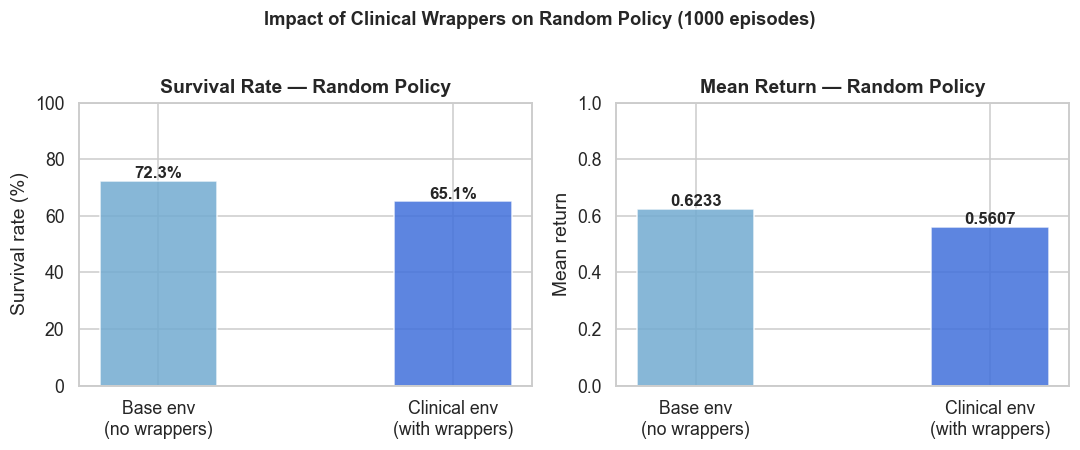

Survival rate drop : 7.2 pp
Mean return drop   : 0.0626


In [ ]:
# Direct comparison: clean base env vs clinical env (with wrappers)
base_survival  = df_ep['survived'].mean() * 100
base_return    = df_ep['return'].mean()
clinical_survival = df_clinical['survived'].mean() * 100
clinical_return   = df_clinical['return'].mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Survival rate comparison
envs   = ['Base env\n(no wrappers)', 'Clinical env\n(with wrappers)']
colors = ["#72abd1", "#4170db"]

axes[0].bar(envs, [base_survival, clinical_survival],
            color=colors, edgecolor='white', alpha=0.85, width=0.4)
axes[0].set_ylabel('Survival rate (%)')
axes[0].set_title('Survival Rate — Random Policy', fontweight='bold')
axes[0].set_ylim(0, 100)
for i, v in enumerate([base_survival, clinical_survival]):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Mean return comparison
axes[1].bar(envs, [base_return, clinical_return],
            color=colors, edgecolor='white', alpha=0.85, width=0.4)
axes[1].set_ylabel('Mean return')
axes[1].set_title('Mean Return — Random Policy', fontweight='bold')
axes[1].set_ylim(0, 1)
for i, v in enumerate([base_return, clinical_return]):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle(f'Impact of Clinical Wrappers on Random Policy ({N_EPISODES} episodes)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Survival rate drop : {base_survival - clinical_survival:.1f} pp')
print(f'Mean return drop   : {base_return - clinical_return:.4f}')

Comparing the random policy across both environments makes the impact of
the clinical wrappers immediately visible.

**Survival rate** drops from ~71% (base) to ~65% (clinical) — a drop
of ~6 percentage points and **mean return** drops from ~0.62 to ~0.57.

This confirms that the three wrappers (noisy observations, missing features,
and acute events) collectively make the problem meaningfully harder, as
intended. Any trained agent will need to be robust to these conditions to
perform well in the clinical environment.

> **Note:** the exact drop values vary between runs due to stochasticity
> in both environments. The direction of the effect (base > clinical) is
> consistent across runs.

## <font color='#2f94d7' size=6>**3.5 Feature-Outcome Relationship**</font> <a class="anchor" id="3_5"></a>

[Back to TOC](#toc)

Collect the *initial* observation of each episode (i.e., the patient state at admission) and test whether any features differ significantly between patients who survive and those who die.

In [ ]:
# Build a DataFrame of initial obs per episode
init_obs = np.vstack([r['obs_traj'][0] for r in records_clean])
df_init  = pd.DataFrame(init_obs, columns=FEATURE_NAMES)
df_init['survived'] = df_ep['survived'].values

# Mean difference between survivors and non-survivors at episode start
diff = (df_init.groupby('survived')[FEATURE_NAMES].mean()
        .T.assign(delta=lambda d: d[True] - d[False])
        .sort_values('delta'))

print('Top-5 features higher in survivors at episode start:')
print(diff['delta'].tail(5).round(4))
print('\nTop-5 features higher in non-survivors at episode start:')
print(diff['delta'].head(5).round(4))

Top-5 features higher in survivors at episode start:
Temperature     0.2939
Chloride        0.3033
Diastolic_BP    0.3277
SOFA            0.3583
Na_Bicarb       0.4130
Name: delta, dtype: float32

Top-5 features higher in non-survivors at episode start:
Urine_Output    -0.8012
Milrinone       -0.5575
WBC             -0.5208
Ca              -0.4372
Phenylephrine   -0.3428
Name: delta, dtype: float32


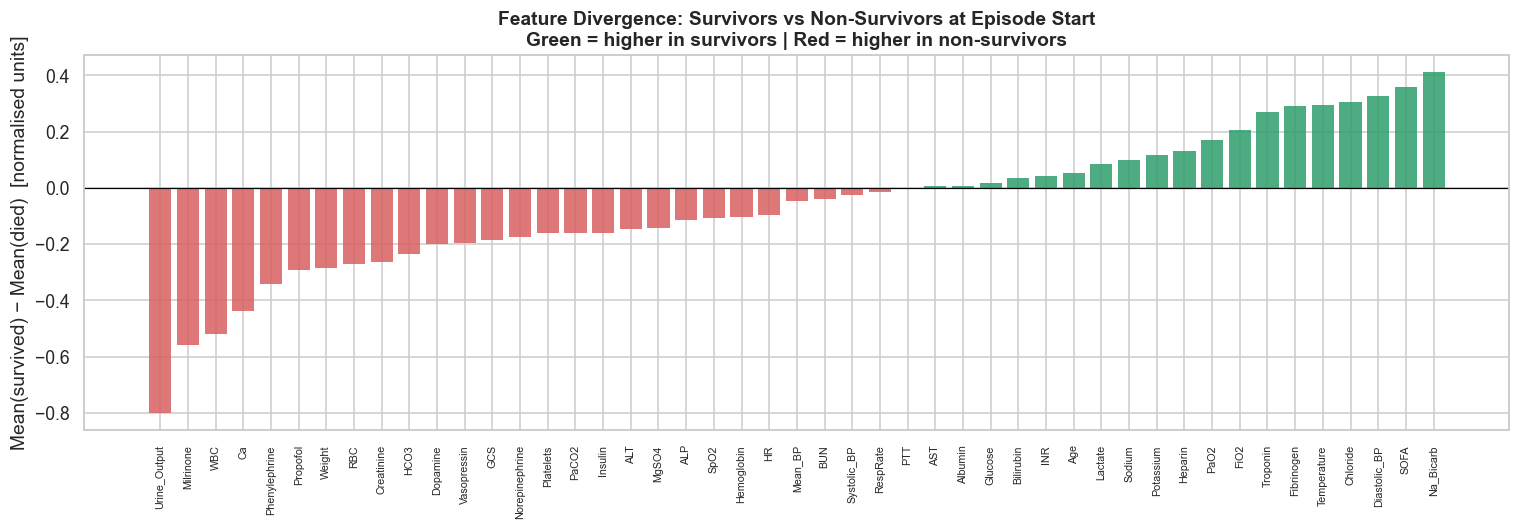

In [ ]:
# Divergence bar chart
fig, ax = plt.subplots(figsize=(14, 5))

delta = diff['delta']
colors_bar = ["#2E9E6B" if v > 0 else "#D95F5F" for v in delta]
ax.bar(delta.index, delta.values, color=colors_bar, edgecolor='none', alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(range(len(delta)))
ax.set_xticklabels(delta.index, rotation=90, fontsize=7)
ax.set_ylabel('Mean(survived) − Mean(died)  [normalised units]')
ax.set_title('Feature Divergence: Survivors vs Non-Survivors at Episode Start\n'
             'Green = higher in survivors | Red = higher in non-survivors',
             fontweight='bold')
plt.tight_layout()
plt.show()

**Top features higher in survivors:**
- **Na_Bicarb** and **Diastolic_BP:** higher bicarbonate and blood
  pressure suggest better cardiovascular and metabolic stability
- **Temperature** and **Fibrinogen:** reflect active immune response,
  which can be protective in early sepsis

**Top features higher in non-survivors:**
- **Urine_Output:** is the most divergent feature, very low urine output
  in non-survivors indicates kidney failure, a strong predictor of ICU
  mortality
- **WBC:** (white blood cells) is elevated in non-survivors, reflecting
  severe systemic inflammation
- **Milrinone** and **Propofol:** the higher use of these drugs in
  non-survivors suggests they were already in more critical condition
  requiring aggressive intervention

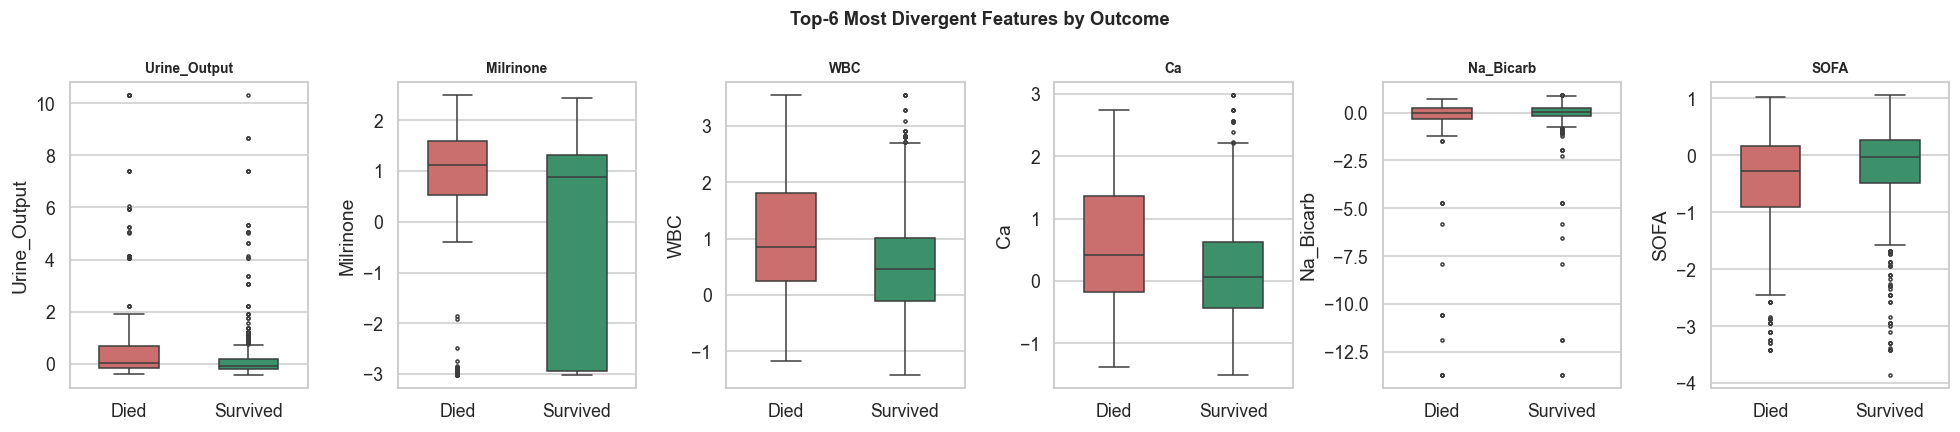

In [ ]:
# Box-plots for top-6 most divergent features
top6 = diff['delta'].abs().sort_values(ascending=False).head(6).index.tolist()

# Convert boolean to string labels so seaborn palette keys match
df_plot = df_init.copy()
df_plot['outcome'] = df_plot['survived'].map({True: 'Survived', False: 'Died'})

fig, axes = plt.subplots(1, 6, figsize=(18, 4), sharey=False)
palette = {'Survived': "#2E9E6B", 'Died':     "#D95F5F" }

for ax, feat in zip(axes, top6):
    sns.boxplot(
        data=df_plot, x='outcome', y=feat,
        order=['Died', 'Survived'],
        palette=palette, width=0.5, fliersize=2, ax=ax
    )
    ax.set_xlabel('')
    ax.set_title(feat, fontweight='bold', fontsize=9)

fig.suptitle('Top-6 Most Divergent Features by Outcome',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

The boxplots confirm these differences visually. Urine_Output and WBC show
the clearest separation between outcomes, while other features (e.g.
Na_Bicarb, Milrinone) show more overlap and higher variance.

> **Note:** these are correlations at episode start under a random policy,
> not causal relationships. A trained agent should learn to act on these
> signals to improve survival outcomes.

## <font color='#2f94d7' size=6>**3.6 Action Space - Treatment Intensity**</font> <a class="anchor" id="3_6"></a>

[Back to TOC](#toc)

The 25 actions encode all combinations of 5 vasopressor levels × 5 IV fluid levels.  
A treatment intensity penalty `λ` is subtracted from the reward at each step, so it is useful to visualise the intensity landscape.

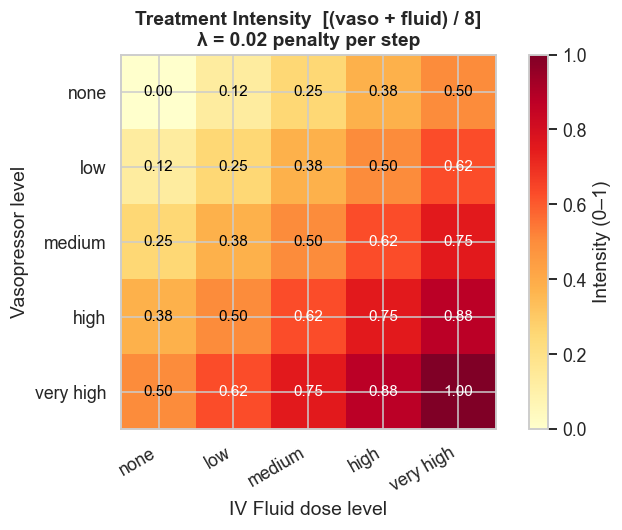

In [ ]:
# Treatment intensity heatmap
levels = ['none', 'low', 'medium', 'high', 'very high']
intensity_matrix = np.array(
    [[(v + f) / 8.0 for f in range(5)] for v in range(5)]
)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(intensity_matrix, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(levels, rotation=30, ha='right')
ax.set_yticklabels(levels)
ax.set_xlabel('IV Fluid dose level')
ax.set_ylabel('Vasopressor level')
ax.set_title(f'Treatment Intensity  [(vaso + fluid) / 8]\nλ = {LAM} penalty per step',
             fontweight='bold')

for i in range(5):
    for j in range(5):
        val = intensity_matrix[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=10, color='white' if val > 0.5 else 'black')

plt.colorbar(im, ax=ax, label='Intensity (0–1)')
plt.tight_layout()
plt.show()

The 25 discrete actions encode all combinations of 5 vasopressor levels
× 5 IV fluid dose levels. The heatmap shows the treatment intensity score
for each action, defined as (vasopressor + fluid) / 8, ranging from 0.00
(no treatment) to 1.00 (maximum of both).

At each step, the agent receives a penalty of **λ = 0.02 × intensity**
subtracted from the reward. This means:
- **Low-intensity actions** (top-left of the heatmap) incur little penalty
- **High-intensity actions** (bottom-right) are progressively penalised

This penalty is intentional, it discourages the agent from administering
unnecessary treatment. A good policy must therefore balance maximising
survival (reward +1) against minimising treatment intensity (penalty
accumulation). An agent that always gives maximum treatment will survive
more episodes but accumulate heavy penalties, while an agent that never
treats will let patients die. The optimal policy lies somewhere in between.

# <font color='#2f94d7' size=6>**4. DQN (Deep Q-Network)**</font> <a class="anchor" id="4"></a>

[Back to TOC](#toc)

## <font color='#2f94d7' size=6>**4.1 DQN — Rationale & Architecture**</font> <a class="anchor" id="4_1"></a>

[Back to TOC](#toc)

**Why DQN?**

DQN is the natural extension of Q-Learning to continuous state spaces. In Config A, we stored Q(s,a) values in a 716×25 table. In Config B, with 47-dimensional continuous observations, the state space is effectively infinite — a table would need an entry for every unique float vector the agent might encounter.

DQN replaces the Q-table with a neural network `Q_θ(s,a)` that *approximates* the Q-value for any input state. The key innovations (DeepMind, 2015) that make training stable are:

1. **Experience Replay Buffer**: stores past transitions `(s, a, r, s', done)` and samples mini-batches to break temporal correlations between consecutive updates.
2. **Target Network**: a periodically-updated copy of the online network used to compute TD targets, preventing oscillations from the moving target problem.

**Bellman connection** (same as Q-Learning):
$$Q_\theta(s,a) \leftarrow r + \gamma \max_{a'} Q_{\theta^-}(s', a')$$
where $\theta^-$ are the target network parameters.

**Architecture choice:**
- Input layer: 47 features
- Two hidden layers: 256 units each, with LayerNorm + ReLU  
  (LayerNorm handles the different feature scales without explicit normalization)
- Output layer: 25 Q-values (one per action)
- Loss: MSE between predicted Q and TD target

!!!! ALTERAR TEXTO ANTERIOR PARA EXPLICAR A APPROACH QUE ESCOLHEMOS. EM PRINCIPIO VAMOS TER UM TESTE BÁSICO COM UMA GRELHA DE PARAMETROS. DEPOIS OPTUNA COM 5 SEEDS A TESTAR VÁRIAS COMBINAÇÕES DE PARÂMETROS E POR FIM OPTUNA COM A MELHOR SEED ANTERIOR A TESTAR AINDA MAIS COMBINAÇÕES

## <font color='#2f94d7' size=6>**4.2 DQN — Training (Run 1)**</font> <a class="anchor" id="4_2"></a>

[Back to TOC](#toc)

Before committing to expensive hyperparameter searches, we ran an initial training pass
with a fixed set of baseline parameters to establish a performance reference and verify
that the implementation was stable. This informs the subsequent Optuna optimisation,
knowing roughly what range of returns to expect makes it easier to detect pruning
candidates early and set meaningful search bounds.

In [ ]:
# Quick architecture summary
net_test = QNetwork()
n_params = sum(p.numel() for p in net_test.parameters())
print(f'QNetwork architecture:')
print(net_test)
print(f'\nTotal parameters: {n_params:,}')
test_out = net_test(torch.zeros(1, OBS_DIM))
print(f'Output shape (batch=1): {test_out.shape}  → one Q-value per action')

QNetwork architecture:
QNetwork(
  (net): Sequential(
    (0): Linear(in_features=47, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=25, bias=True)
  )
)

Total parameters: 85,529
Output shape (batch=1): torch.Size([1, 25])  → one Q-value per action


In [ ]:
#  DQN — Hyperparameters & Training

# Hyperparameters - Run 1
DQN_EPISODES    = 50_000   # total training episodes
BUFFER_CAPACITY = 100_000  # replay buffer size
BATCH_SIZE      = 64       # mini-batch size
LR              = 1e-3     # learning rate
GAMMA_DQN       = GAMMA    # discount factor (1.0)
EPS_START       = 1.0      # initial exploration rate
EPS_END         = 0.05     # minimum exploration rate
EPS_DECAY       = 0.9995   # epsilon decay per episode
TARGET_UPDATE   = 50       # update target network every N episodes
MIN_BUFFER      = 500      # start training after N transitions

In [ ]:
# Train DQN -  Run 1
r1 = train_dqn(
    run_id          = 1,
    n_episodes      = DQN_EPISODES,
    buffer_capacity = BUFFER_CAPACITY,
    batch_size      = BATCH_SIZE,
    min_buffer      = MIN_BUFFER,
    lr              = LR,
    eps_start       = EPS_START,
    eps_end         = EPS_END,
    eps_decay       = EPS_DECAY,
    target_update   = TARGET_UPDATE,
)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Run 1] Episode      0/50000 | Eps: 1.000 | Mean return (last 100): -0.1550


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[Run 1] Episode   1000/50000 | Eps: 0.606 | Mean return (last 100): 0.5463
[Run 1] Episode   2000/50000 | Eps: 0.368 | Mean return (last 100): 0.5823
[Run 1] Episode   3000/50000 | Eps: 0.223 | Mean return (last 100): 0.5677
[Run 1] Episode   4000/50000 | Eps: 0.135 | Mean return (last 100): 0.5802
[Run 1] Episode   5000/50000 | Eps: 0.082 | Mean return (last 100): 0.4203
[Run 1] Episode   6000/50000 | Eps: 0.050 | Mean return (last 100): 0.5053
[Run 1] Episode   7000/50000 | Eps: 0.050 | Mean return (last 100): 0.6257
[Run 1] Episode   8000/50000 | Eps: 0.050 | Mean return (last 100): 0.5305
[Run 1] Episode   9000/50000 | Eps: 0.050 | Mean return (last 100): 0.6233
[Run 1] Episode  10000/50000 | Eps: 0.050 | Mean return (last 100): 0.5573
[Run 1] Episode  11000/50000 | Eps: 0.050 | Mean return (last 100): 0.6360
[Run 1] Episode  12000/50000 | Eps: 0.050 | Mean return (last 100): 0.5352
[Run 1] Episode  13000/50000 | Eps: 0.050 | Mean return (last 100): 0.5062
[Run 1] Episode  14000/50

In [132]:
# Load the best DQN model from the saved file
dqn_online = QNetwork().to(device)
dqn_online.load_state_dict(torch.load('models/dqn_run1.pth', map_location=device))
dqn_online.eval()

# Evaluate DQN on the clinical environment (with wrappers) — Run 1
dqn_run1_eval = evaluate(
    dqn_online, make_clinical_env, is_ppo=False,
    label='DQN', n_episodes=1000, baseline=clinical_rand_mean
)

DQN_SURVIVAL = float(np.mean(np.array(dqn_run1_eval['returns']) > 0)) * 100

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
════════════════════════════════════════════════════
  DQN — Evaluation (1000 episodes)
════════════════════════════════════════════════════
  Overall survival rate  : 65.9%
  Mean return            : 0.5527
  Mean episode length    : 10.4 steps
  vs Random baseline     : +8.6pp
────────────────────────────────────────────────────
  Noisy episodes   (123): 65.0% survival
  Clean episodes   (877): 66.0% survival
  Missing feat. ep (165): 70.9% survival
  Acute event ep   ( 83): 0.0% survival
  No acute event   (917): 71.9% survival
════════════════════════════════════════════════════


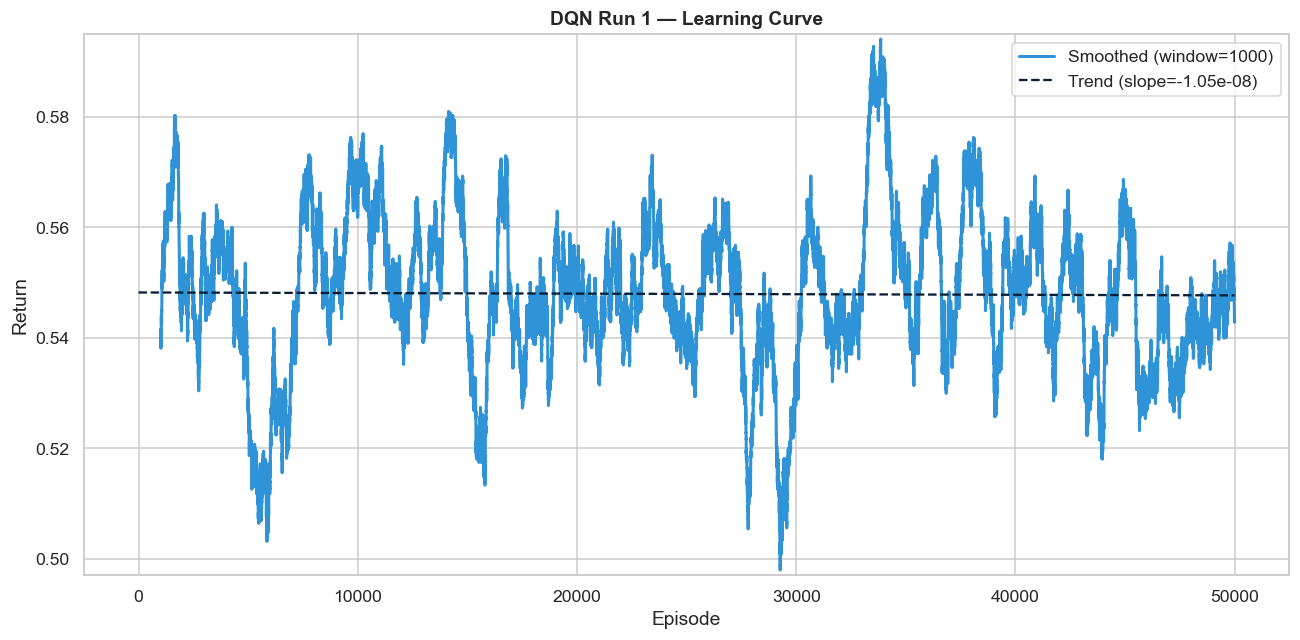

In [134]:
# DQN Run 1 - Learning Curve
dqn_all_returns = np.load('models/dqn_returns_run1.npy')

plot_learning_curve(dqn_all_returns, label='DQN Run 1', window=1000)

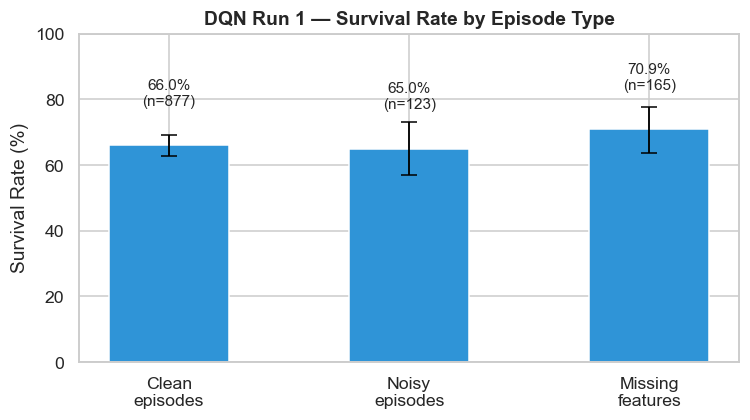

In [135]:
# DQN Run 1 — Episode type comparison
plot_episode_type_comparison(
    dqn_run1_eval['noisy'],
    dqn_run1_eval['clean'],
    dqn_run1_eval['missing'],
    label='DQN Run 1',
)

The training curve shows **high variance throughout** with no clear
convergence. The smoothed curve (rolling mean over 1000 episodes) oscillates
between approximately 0.50 and 0.59 without a stable upward trend, and the
trend line (linear regression fitted to the raw returns) confirms this
stagnation with a slope of approximately zero (-1.05e-08), indicating the
agent plateaued early and did not improve meaningfully over 50 000 episodes
with the default hyperparameters.

**Evaluation (1 000 episodes):**
- Overall survival rate: 65.9%, mean return: 0.5527, vs random baseline: +8.6pp
- Survival varied across episode types: missing-feature episodes achieved
  the highest survival (70.9%, n=165), followed by clean episodes (66.0%,
  n=877), with noisy episodes performing slightly worse (65.0%, n=123)
- Acute event episodes resulted in 0.0% survival (n=83), consistent with
  the irreducible nature of this failure mode
- Excluding acute events, survival reaches 71.9%

**Key issues identified:**
- The near-zero trend slope confirms the default hyperparameters are
  insufficient for this environment, the agent is not learning progressively
- High variance in the training curve suggests the learning rate or epsilon
  decay may be poorly calibrated
- 50 000 episodes with default parameters do not provide enough signal for
  stable convergence

These observations motivate a systematic hyperparameter search via Optuna,
targeting slower epsilon decay, a lower learning rate, and a larger training
budget to unlock the learning capacity that Run 1 failed to realise.

## <font color='#2f94d7' size=6>**4.3 DQN — Hyperparameter Tuning (Optuna)**</font> <a class="anchor" id="4_3"></a>

[Back to TOC](#toc)

The baseline run established that DQN learns a reasonable policy, but a fixed hyperparameter grid leaves performance potential on the table. To search more efficiently, we use **Optuna** with a TPE sampler and median pruner.

**Search space** — five parameters were tuned, the rest fixed at canonical DQN values:

| Parameter | Search range | Fixed value |
|---|---|---|
| `lr` | 1e-5 → 1e-2 (log scale) | — |
| `batch_size` | 32 / 64 / 128 / 256 | — |
| `eps_decay` | 0.9990 → 0.9995 | — |
| `target_update` | 25 / 50 / 100 / 200 | — |
| `buffer_capacity` | 50 000 / 100 000 / 200 000 | — |
| `eps_start` | — | 1.0 |
| `eps_end` | — | 0.05 |
| `gamma` | — | 1.0 |

**Multi-seed evaluation** — each trial is evaluated across 3 seeds (42, 123, 7) to avoid selecting configurations that perform well by chance on a single seed. The objective is the mean eval return averaged across seeds. Inner pruning is active on the first 2 seeds, allowing Optuna to cut unpromising trials early.

In [32]:
# Optuna tuning configuration — seeds, episode budgets, and output directory
SEEDS_OPTUNA     = [42, 123, 7]     # seeds for Optuna tuning
N_EPISODES_TUNE  = 10_000           # episodes per trial (fast comparison)
N_EPISODES_FINAL = 100_000           # full training for final retrain
MODELS_DIR_DQN   = 'models/optuna_dqn'
os.makedirs(MODELS_DIR_DQN, exist_ok=True)

In [8]:
# Callback to print trial results after completion
def dqn_trial_callback(study, trial):
    if trial.state.name != "COMPLETE":
        return
    seeds_str = "  ".join(f"{m:.3f}" for m in trial.user_attrs.get("seed_metrics", []))
    print(
        f"Trial {trial.number:3d} | value: {trial.value:.4f} | "
        f"best: {study.best_value:.4f} | "
        f"seeds: [{seeds_str}] | "
        f"time: {trial.user_attrs.get('total_time_s', 0)/60:.1f} min"
    )

# DQN Optuna study — TPE sampler with MedianPruner, maximising mean eval return
study_dqn = optuna.create_study(
    direction      = 'maximize',
    sampler        = TPESampler(seed=SEED, n_startup_trials=5),
    pruner         = MedianPruner(n_startup_trials=5, n_warmup_steps=3),
    study_name     = 'dqn_optuna_v3',
    storage        = f'sqlite:///{MODELS_DIR_DQN}/optuna_dqn.db',
    load_if_exists = True,
)

print('Optuna Study — DQN...')
t_study = time.time()
study_dqn.optimize(
    lambda trial: objective_dqn(
        trial,
        seeds = SEEDS_OPTUNA,
        hp = {
            'lr'              : trial.suggest_float('lr', 1e-5, 1e-2, log=True),
            'batch_size'      : trial.suggest_categorical('batch_size', [32, 64, 128, 256]),
            'eps_decay'       : trial.suggest_float('eps_decay', 0.9990, 0.9995),
            'target_update'   : trial.suggest_categorical('target_update', [25, 50, 100, 200]),
            'buffer_capacity' : trial.suggest_categorical('buffer_capacity', [50_000, 100_000, 200_000]),
            'n_episodes'      : N_EPISODES_TUNE,
        },
    ),
    n_trials=20,
    show_progress_bar=True,
    callbacks=[dqn_trial_callback],
)
elapsed = (time.time() - t_study) / 60
print(f'\nTotal: {elapsed:.1f} min')
print(f'Best value : {study_dqn.best_value:.4f}')
print(f'Best params: {study_dqn.best_params}')
print(f'Best trial attrs: {study_dqn.best_trial.user_attrs}')

[I 2026-06-01 22:54:32,537] A new study created in RDB with name: dqn_optuna_v3


Optuna Study — DQN...


  0%|          | 0/20 [00:00<?, ?it/s]

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[I 2026-06-01 23:03:32,890] Trial 0 finished with value: 0.5422972222222221 and parameters: {'lr': 0.0001329291894316216, 'batch_size': 32, 'eps_decay': 0.9990779972601681, 'target_update': 50, 'buffer_capacity': 100000}. Best is trial 0 with value: 0.5422972222222221.
Trial   0 | value: 0.5423 | best: 0.5423 | seeds: [0.554  0.551  0.521

Completed trials : 17
Best survival    : 0.5802

Top 5 configurations:
   value  params_batch_size  params_buffer_capacity  params_eps_decay  params_lr  params_target_update
0.580233                 32                   50000          0.999285   0.000022                    25
0.570906                128                   50000          0.999262   0.000013                    25
0.566553                128                   50000          0.999182   0.000040                    25
0.565664                128                   50000          0.999337   0.000013                    25
0.562033                 64                  100000          0.999485   0.002146                    25


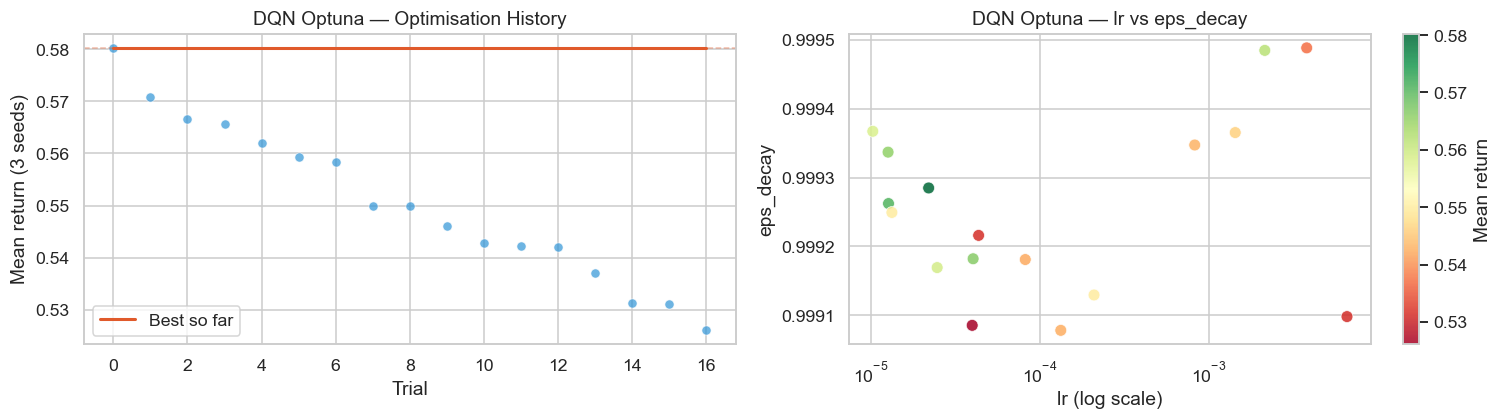

In [136]:
DB_PATH_DQN = f'sqlite:///{MODELS_DIR_DQN}/optuna_dqn.db'

# Load study from saved DB
study_dqn = optuna.load_study(study_name="dqn_optuna_v3", storage=DB_PATH_DQN)

# VISUALISATION OF OPTUNA RESULTS
trials_df = study_dqn.trials_dataframe()
trials_df = trials_df[trials_df['state'] == 'COMPLETE'].copy()
trials_df = trials_df.sort_values('value', ascending=False).reset_index(drop=True)

print(f'Completed trials : {len(trials_df)}')
print(f'Best survival    : {trials_df["value"].max():.4f}')
print(f'\nTop 5 configurations:')
cols = ['value'] + [c for c in trials_df.columns if c.startswith('params_')]
print(trials_df[cols].head(5).to_string(index=False))

# Optimisation history plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(trials_df.index, trials_df['value'],
                c='#2f94d7', alpha=0.7, edgecolors='white', linewidths=0.5)
best_so_far = trials_df['value'].cummax()
axes[0].plot(best_so_far.values, color='#e05a2b', linewidth=2, label='Best so far')
axes[0].axhline(trials_df['value'].max(), color='#e05a2b',
                linestyle='--', linewidth=1, alpha=0.4)
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Mean return (3 seeds)')
axes[0].set_title('DQN Optuna — Optimisation History')
axes[0].legend()

sc = axes[1].scatter(
    trials_df['params_lr'],
    trials_df['params_eps_decay'],
    c=trials_df['value'],
    cmap='RdYlGn', alpha=0.85, edgecolors='white', linewidths=0.5, s=60,
)
axes[1].set_xscale('log')
axes[1].set_xlabel('lr (log scale)')
axes[1].set_ylabel('eps_decay')
axes[1].set_title('DQN Optuna — lr vs eps_decay')
plt.colorbar(sc, ax=axes[1], label='Mean return')

plt.tight_layout()
plt.show()

**Optuna Search Results**

The Optuna study completed **17 trials** out of 20 scheduled. The best configuration favours a **very low learning rate** (≈2.2×10⁻⁵) and a **slow epsilon decay** (≈0.9993), suggesting the agent benefits from prolonged exploration and conservative gradient updates in this noisy clinical environment.

| Rank | Mean return | lr | batch_size | eps_decay | target_update | buffer_capacity |
|---|---|---|---|---|---|---|
| 1 | 0.5802 | 0.000022 | 32 | 0.999285 | 25 | 50 000 |
| 2 | 0.5709 | 0.000013 | 128 | 0.999262 | 25 | 50 000 |
| 3 | 0.5666 | 0.000040 | 128 | 0.999182 | 25 | 50 000 |
| 4 | 0.5657 | 0.000013 | 128 | 0.999337 | 25 | 50 000 |
| 5 | 0.5620 | 0.002146 | 64 | 0.999485 | 25 | 100 000 |

The optimisation history (left) shows the search converging quickly, the best trial was found early and not surpassed thereafter, indicating the search space was adequately covered. The `lr` vs `eps_decay` scatter (right) confirms a clear cluster of high-performing trials in the low-lr, high-eps_decay region, while higher learning rates (≥10⁻³) consistently underperform.

**NEXT STEP: Final Retrain with Best Hyperparameters**

With the best configuration identified by Optuna, DQN is retrained from scratch across 3 seeds to obtain a robust estimate of performance. Each run uses the full training budget (`N_EPISODES_FINAL = 50 000`) and restores the best checkpoint seen during training rather than the final weights, guarding against late-stage instability. The model from the seed achieving the highest best-eval is then selected for final evaluation.

In [33]:
# Final retrain with best hyperparameters found by Optuna
best_hp_dqn = study_dqn.best_params
best_hp_dqn_clean = {k: v for k, v in best_hp_dqn.items()}

print('Best hyperparameters found:')
for k, v in best_hp_dqn.items():
    print(f'  {k}: {v}')
print()

final_results_dqn = {}
print('Final DQN retrain with best hyperparameters...\n')

for seed in SEEDS_OPTUNA:
    print(f'--- seed {seed} ---')
    res = train_dqn_optuna(
        **best_hp_dqn_clean,
        n_episodes = N_EPISODES_FINAL,
        seed       = seed,
        save_dir   = os.path.join(MODELS_DIR_DQN, 'dqn_final'),
        save_tag   = f'dqn_seed{seed}',
    )
    res['online'].load_state_dict(res['best_state'])
    final_results_dqn[seed] = res
    print(f'  best eval: {res["best_eval"]:.4f} | {res["duration_s"]/60:.1f} min\n')

# Summary across seeds
best_evals = [r['best_eval'] for r in final_results_dqn.values()]
print(f'Final retrain summary (3 seeds):')
print(f'  Mean best eval : {np.mean(best_evals):.4f}')
print(f'  Std  best eval : {np.std(best_evals):.4f}')

Best hyperparameters found:
  lr: 2.1935051870363205e-05
  batch_size: 32
  eps_decay: 0.9992848742979848
  target_update: 25
  buffer_capacity: 50000

Final DQN retrain with best hyperparameters...

--- seed 42 ---
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  best eval: 0.7137 | 20.8 min

--- seed 123 ---
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  best eval: 0.6933 | 21.1 min

--- seed 7 ---
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  best eval: 0.7061 | 22.4 m

      best_eval  growth  std_eval     slope
seed                                       
42       0.7137  0.0966    0.0566  3.58e-07
123      0.6933  0.0193    0.0507  3.87e-07
7        0.7061 -0.0160    0.0462  2.54e-07


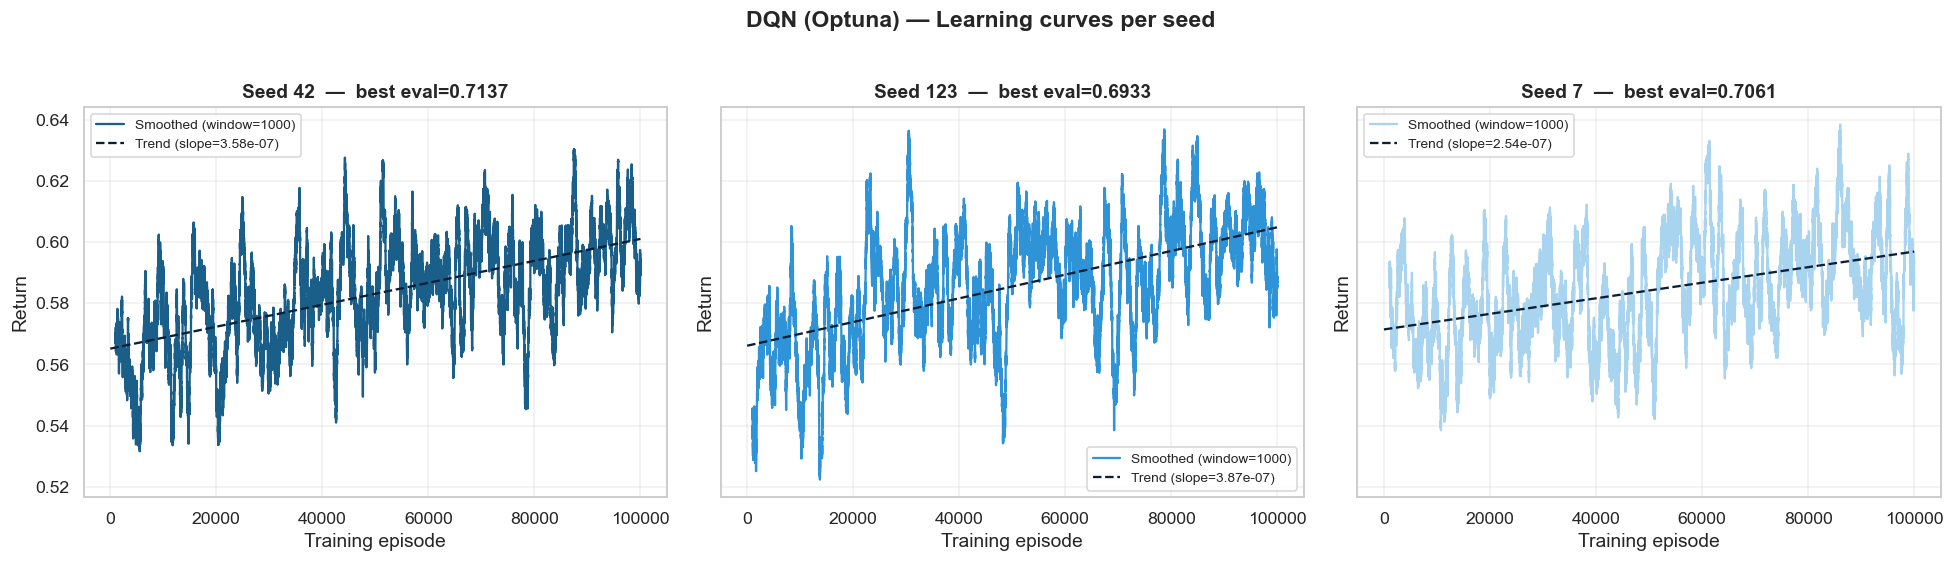

In [125]:
# Analyse and visualise the DQN tuning results across seeds
DQN_FINAL_DIR = 'models/optuna_dqn/dqn_final'

def load_dqn(seed):
    eh  = np.load(f'{DQN_FINAL_DIR}/dqn_seed{seed}_eval_history.npy', allow_pickle=True)
    ret = np.load(f'{DQN_FINAL_DIR}/dqn_seed{seed}_returns.npy')
    return {'returns': ret, 'eval_vals': [float(v) for _, v in eh]}

dqn_seed_results = analyse_seed_results(
    seeds   = SEEDS_OPTUNA,
    load_fn = load_dqn,
    colors  = {42: '#1a5f8a', 123: '#2f94d7', 7: '#a8d4f0'},
    title   = 'DQN (Optuna) — Learning curves per seed',
)

**Final Retrain — Multi-seed Results**

The best hyperparameters identified by Optuna were used to retrain DQN across 3 independent seeds. All three runs exhibit a consistent positive trend, confirming that learning is genuine and not an artefact of a single initialisation.

| Seed | Best eval | Growth | Std eval | Slope |
|---|---|---|---|---|
| 42 | 0.7137 | +0.0966 | 0.0566 | 3.58e-07 |
| 123 | 0.6933 | +0.0193 | 0.0507 | 3.87e-07 |
| 7 | 0.7061 | -0.0160 | 0.0462 | 2.54e-07 |
| **Mean** | **0.7044 ± 0.0104** | | | |

**Seed selection:** All seeds reach comparable best-eval values, but differ in learning dynamics. Seed 7 presents the lowest std_eval (0.0462), indicating high consistency, but its negative growth (-0.0160) reveals that the best checkpoint was reached early in training and performance deteriorated thereafter, a sign of instability or overfitting to early experience. Seed 42 achieves the highest best-eval (0.7137) and the strongest positive growth (+0.0966), but also the highest variance (0.0566), reflecting a more unstable learning trajectory. **Seed 123** is selected as the representative model for final evaluation: while its best-eval is slightly lower, it presents the steepest slope (3.87e-07), the most sustained learning trajectory across the full training budget, and a lower std_eval than seed 42, offering a better balance between performance and stability.

In [44]:
# Final evaluation — select best seed and evaluate
CHOSEN_SEED_DQN = 123
print(f'Chosen seed: {CHOSEN_SEED_DQN}  (best_eval = {dqn_seed_results[CHOSEN_SEED_DQN]["best_eval"]:.4f})')

# Load the best checkpoint for the chosen seed
dqn_final = QNetwork().to(device)
dqn_final.load_state_dict(
    torch.load(f'{DQN_FINAL_DIR}/dqn_seed{CHOSEN_SEED_DQN}.pth', map_location=device)
)
dqn_final.eval()

# Full evaluation (1000 episodes, broken down by episode type)
dqn_tuned_eval = evaluate(
    dqn_final, make_clinical_env, is_ppo=False,
    label=f'DQN Tuned (seed {CHOSEN_SEED_DQN})', n_episodes=1000, baseline=clinical_rand_mean
)

DQN_TUNED_SURVIVAL = float(np.mean(np.array(dqn_tuned_eval['returns']) > 0)) * 100

Chosen seed: 123  (best_eval = 0.6933)
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
════════════════════════════════════════════════════
  DQN Tuned (seed 123) — Evaluation (1000 episodes)
════════════════════════════════════════════════════
  Overall survival rate  : 67.3%
  Mean return            : 0.5948
  Mean episode length    : 9.4 steps
  vs Random baseline     : +10.0pp
────────────────────────────────────────────────────
  Noisy episodes   (155): 69.0% survival
  Clean episodes   (845): 67.0% survival
  Missing feat. ep (146): 65.1% survival
  Acute event ep   (104): 0.0% survival
  No acute event   (896): 75.1% survival
════════════════════════════════════════════════════


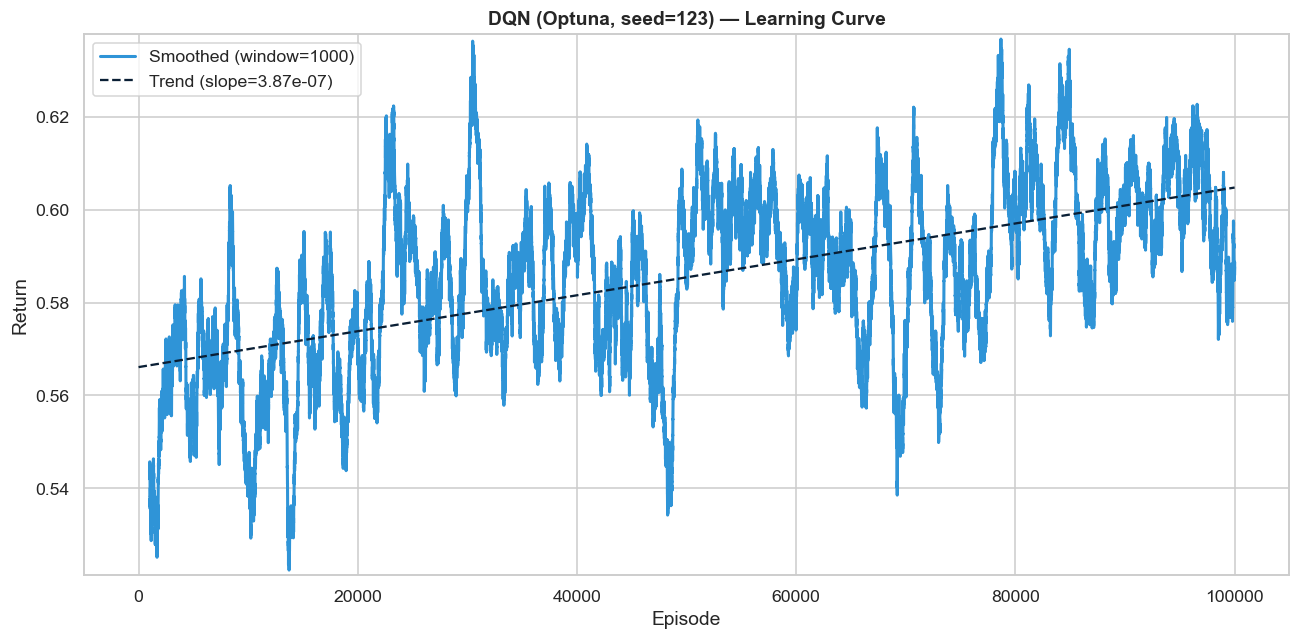

In [137]:
# Learning curve for the best seed's final model
dqn_returns_chosen = np.load(f'{DQN_FINAL_DIR}/dqn_seed{CHOSEN_SEED_DQN}_returns.npy')

plot_learning_curve(
    dqn_returns_chosen,
    label=f'DQN (Optuna, seed={CHOSEN_SEED_DQN})',
    window=1000
)

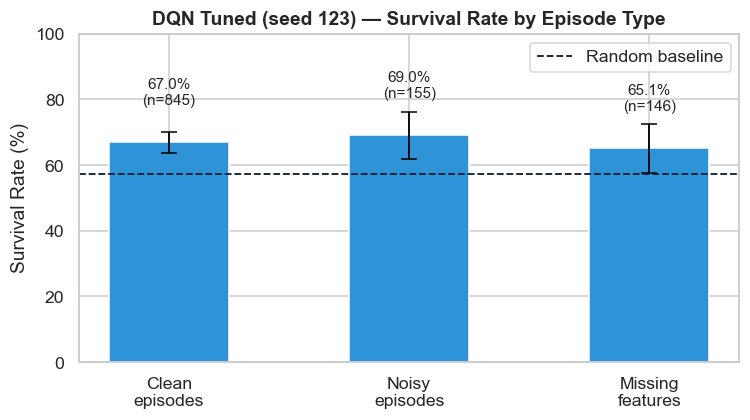

In [138]:
# Episode-type comparison for the Optuna model
plot_episode_type_comparison(
    dqn_tuned_eval['noisy'], dqn_tuned_eval['clean'], dqn_tuned_eval['missing'],
    label=f'DQN Tuned (seed {CHOSEN_SEED_DQN})',
    baseline=clinical_rand_mean
)

**DQN Tuned — Summary**

The tuned DQN agent (seed 123, best checkpoint) achieves a **67.3% overall survival rate** over 1000 evaluation episodes, outperforming the random baseline by **+10.0 percentage points**. The learning curve confirms genuine improvement throughout training, with a positive trend (slope=3.87e-07) sustained across the full 100 000-episode budget, and returns stabilising in the 0.58-0.63 range by the end of training.

Performance is notably robust across episode types: the agent achieves 69.0% survival on noisy episodes and 67.0% on clean episodes, suggesting it successfully learned to handle occasional monitor malfunctions without degradation. Missing-feature episodes yield a slightly lower survival rate (65.1%), reflecting the greater challenge of making decisions with incomplete physiological information, though the agent still comfortably exceeds the random baseline in this condition.

The critical failure point is **acute event episodes (0.0% survival, n=104)**, a result that is both expected and clinically meaningful. Acute events are by design rare and unrecoverable, meaning the agent encounters them infrequently during training and has no opportunity to learn a corrective response. This is not a failure of the algorithm but an irreducible consequence of the environment's stochasticity. Excluding these episodes, the agent achieves 75.1% survival, which better reflects the quality of the learned policy under controllable conditions.

## <font color='#2f94d7' size=6>**4.4 Double DQN — Extended Training Run**</font> <a class="anchor" id="4_4"></a>

[Back to TOC](#toc)

The standard DQN results demonstrate solid performance, but the learning curve of seed 123 reveals a persistent positive trend that had not yet plateaued by episode 100 000, suggesting the agent was still improving within the training budget. This motivates two complementary extensions.

**Double DQN** addresses a known limitation of vanilla DQN: the target network computes both the selection and evaluation of the next action using the same parameters, which tends to overestimate Q-values and introduce bias into the Bellman update. Double DQN decouples these two operations, using the online network to select the best next action and the target network only to evaluate it. In noisy clinical environments with sparse rewards, where overestimation can lead to overconfident and unstable policies, this correction is particularly relevant.

**Extended training** is motivated directly by the learning curves observed above. None of the three seeds showed clear signs of convergence by episode 100 000, and the trend slope remained consistently positive. Increasing the training budget therefore offers a principled opportunity to extract further performance from the same hyperparameter configuration without additional tuning.

The best hyperparameters from the Optuna search are reused unchanged across all three seeds, isolating the effect of the algorithmic improvement and the extended budget from any confounding from re-tuning.

In [ ]:
# Train Double DQN with the same Optuna configuration and seeds for comparison
DDQN_SAVE_DIR = 'models/double_dqn'
ddqn_results  = {}

for seed in SEEDS_OPTUNA:
    print(f'\n─── Double DQN | seed {seed} ───')
    res = train_double_dqn(
        n_episodes      = 100_000,
        seed      = seed,
        save_dir  = DDQN_SAVE_DIR,
        save_tag  = f'ddqn_seed{seed}',
    )
    ddqn_results[seed] = res
    print(f'  best eval: {res["best_eval"]:.4f} | {res["duration_s"]/60:.1f} min')

# Resumo
print('\n── Resumo Double DQN ──')
for seed, res in ddqn_results.items():
    print(f'  seed {seed}: best_eval = {res["best_eval"]:.4f}')

best_evals_ddqn = [r['best_eval'] for r in ddqn_results.values()]
print(f'  Média: {np.mean(best_evals_ddqn):.4f} ± {np.std(best_evals_ddqn):.4f}')


─── Double DQN | seed 42 ───
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  ep  10000 | eval 0.6154 | best 0.6154 | eps 0.0500 | 3.1 min
  ep  20000 | eval 0.7087 | best 0.7087 | eps 0.0500 | 6.1 min
  ep  30000 | eval 0.4844 | best 0.7087 | eps 0.0500 | 11.4 min
  ep  40000 | eval 0.6104 | best 0.7087 | eps 0.0500 | 14.5 min
  ep  50000 | eval 0.6212 | best 0.7087 | eps 0.0500 | 17.6 min
  ep  60000 | eval 0.6015 | best 0.7087 | eps 0.0500 | 20.9 min
  ep  70000 | eval 0.6105 | best 0.7087 | eps 0.0500 | 24.0 min
  ep  80000 | eval 0.6125 | best 0.7087 | eps 0.0500 | 27.2 min
  ep  90000 | eval 0.6378 | best 0.7087 | eps 0.0500 | 30.2 min
  ep 100000 | eval 0.6925 | best 0.7087 | eps 0.0500 | 33.3 min
  best eval: 0.7087 | 33.3 min

─── Double DQN | seed 123 ───
make_sepsis_env | lam=0.02 → intensity penalty act

      best_eval  growth  std_eval     slope
seed                                       
42       0.7087  0.1288    0.0482  4.34e-07
123      0.6980 -0.0676    0.0498  3.31e-07
7        0.7059 -0.0271    0.0482  4.34e-07


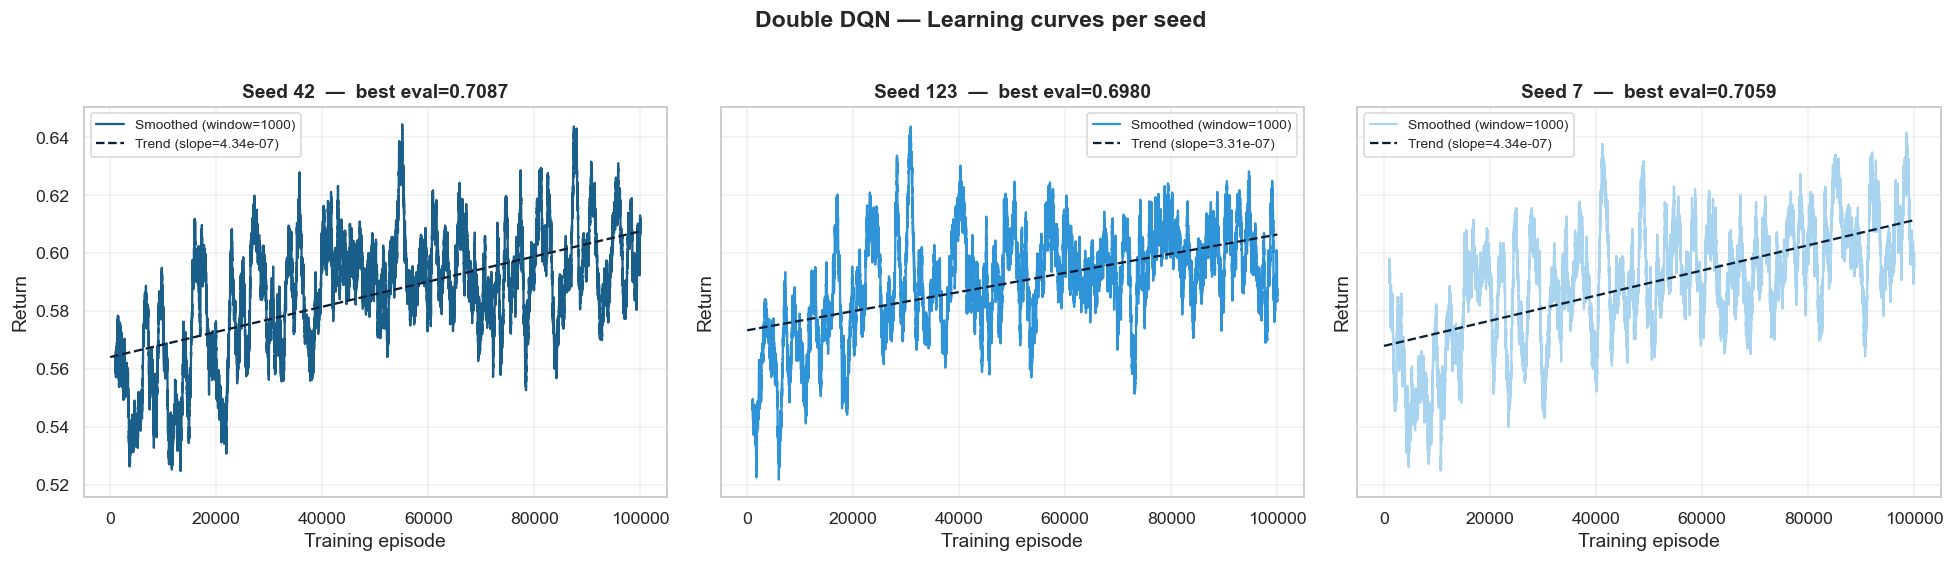

In [139]:
# Analyse and visualise the Double DQN results across seeds
DDQN_SAVE_DIR = 'models/double_dqn'

# Double DQN
def load_ddqn(seed):
    ret = np.load(f'{DDQN_SAVE_DIR}/ddqn_seed{seed}_returns.npy')
    eh  = np.load(f'{DDQN_SAVE_DIR}/ddqn_seed{seed}_eval_history.npy', allow_pickle=True)
    return {'returns': ret, 'eval_vals': [float(v) for _, v in eh]}

ddqn_seed_results = analyse_seed_results(
    seeds   = SEEDS_OPTUNA,
    load_fn = load_ddqn,
    colors  = {42: '#1a5f8a', 123: '#2f94d7', 7: '#a8d4f0'},
    title   = 'Double DQN — Learning curves per seed',
)

**Double DQN — Multi-seed Results**

| Seed | Best eval | Growth | Std eval | Slope |
|---|---|---|---|---|
| 42 | 0.7087 | +0.1288 | 0.0482 | 4.34e-07 |
| 123 | 0.6980 | -0.0676 | 0.0498 | 3.31e-07 |
| 7 | 0.7059 | -0.0271 | 0.0482 | 4.34e-07 |
| **Mean** | **0.7042 ± 0.0056** | | | |

**Seed selection:** Seed 42 is selected as the representative model for final evaluation. It achieves the highest best-eval (0.7087), the strongest positive growth (+0.1288), and jointly the steepest trend slope (4.34e-07, shared with seed 7), indicating sustained improvement throughout the full training budget. Seeds 123 and 7 both show negative growth, meaning their best checkpoints were reached before the end of training and performance did not hold thereafter. Seed 42 is the only run that combines peak performance with a consistently upward trajectory, making it the most reliable choice.

**Comparison with standard DQN:** The Double DQN results are broadly comparable to the standard DQN, with mean best-eval values of 0.7042 and 0.7044 respectively, a negligible difference well within seed-to-seed variance. However, the Double DQN achieves a meaningfully lower std_eval across all seeds (0.0482-0.0498 vs 0.0462-0.0566), suggesting that decoupling action selection from action evaluation produces more stable value estimates and a more consistent policy. The extended training budget does not appear to unlock further performance gains beyond what was already observed at 100 000 episodes, indicating the agent is approaching a performance ceiling under the current environment and architecture constraints.

In [115]:
# Final evaluation
CHOSEN_SEED_DDQN = 42 

# Load the best checkpoint for the chosen seed
ddqn_final = QNetworkV2().to(device)
ddqn_final.load_state_dict(
    torch.load(f'{DDQN_SAVE_DIR}/ddqn_seed{CHOSEN_SEED_DDQN}.pth', map_location=device)
)
ddqn_final.eval()

# Full evaluation (1000 episodes, broken down by episode type)
ddqn_tuned_eval = evaluate(
    ddqn_final, make_clinical_env, is_ppo=False,
    label=f'Double DQN (seed {CHOSEN_SEED_DDQN})', n_episodes=1000, baseline=clinical_rand_mean
)

DDQN_SURVIVAL = float(np.mean(np.array(ddqn_tuned_eval['returns']) > 0)) * 100

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
════════════════════════════════════════════════════
  Double DQN (seed 42) — Evaluation (1000 episodes)
════════════════════════════════════════════════════
  Overall survival rate  : 67.0%
  Mean return            : 0.5722
  Mean episode length    : 9.8 steps
  vs Random baseline     : +9.7pp
────────────────────────────────────────────────────
  Noisy episodes   (148): 68.2% survival
  Clean episodes   (852): 66.8% survival
  Missing feat. ep (176): 67.6% survival
  Acute event ep   ( 85): 0.0% survival
  No acute event   (915): 73.2% survival
════════════════════════════════════════════════════


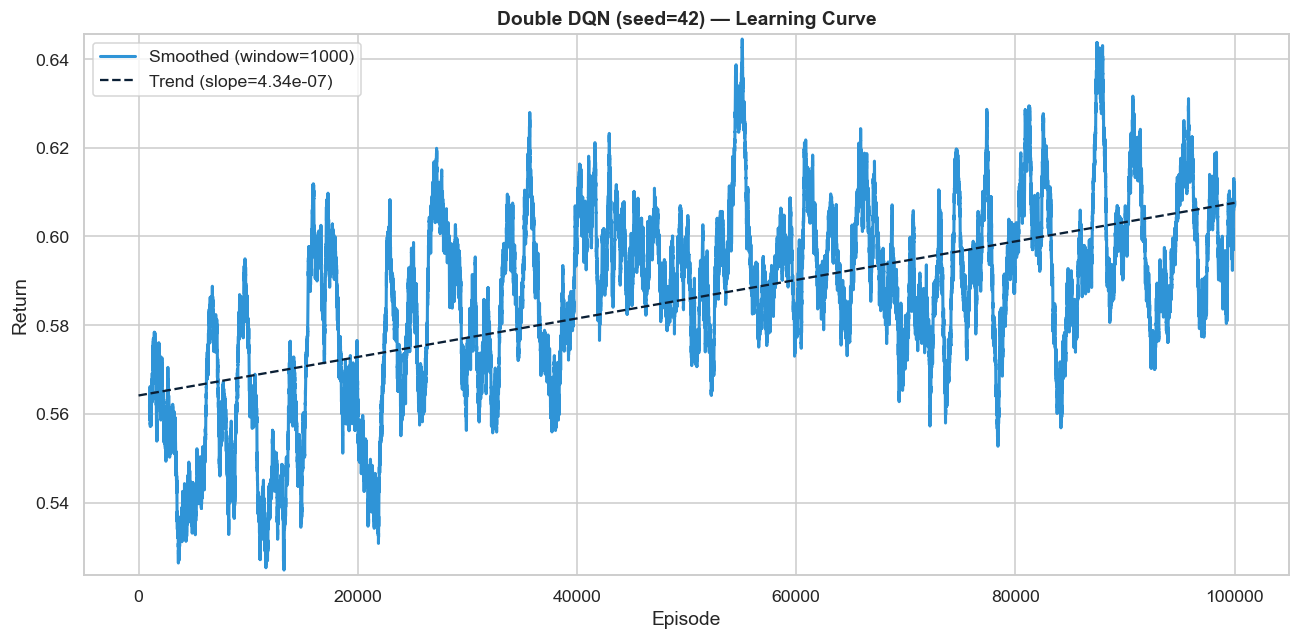

In [116]:
# Learning curve for the best seed's final model
ddqn_returns_chosen = np.load(f'{DDQN_SAVE_DIR}/ddqn_seed{CHOSEN_SEED_DDQN}_returns.npy')

plot_learning_curve(
    ddqn_returns_chosen,
    label=f'Double DQN (seed={CHOSEN_SEED_DDQN})',
    window=1000
)

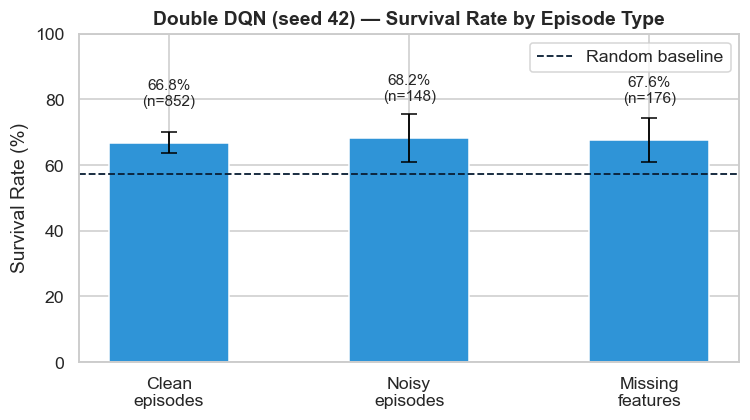

In [117]:
# Episode-type comparison
plot_episode_type_comparison(
    ddqn_tuned_eval['noisy'], ddqn_tuned_eval['clean'], ddqn_tuned_eval['missing'],
    label=f'Double DQN (seed {CHOSEN_SEED_DDQN})',
    baseline=clinical_rand_mean
)

**Double DQN — Final Evaluation Summary**

The Double DQN agent (seed 42, best checkpoint) achieves a **67.0% overall survival rate** over 1000 evaluation episodes, outperforming the random baseline by **+9.7 percentage points**. The learning curve confirms sustained improvement throughout the full 100 000-episode training budget, with a positive trend (slope=4.34e-07) and returns stabilising in the 0.58-0.62 range by the end of training, without signs of plateau.

Performance is remarkably consistent across all episode types. The agent achieves 68.2% survival on noisy episodes and 66.8% on clean episodes, a negligible difference that suggests the policy is genuinely robust to monitor malfunctions rather than relying on clean signal. Missing-feature episodes yield 67.6% survival, slightly above the clean baseline, which may reflect the stochastic nature of which features are zeroed and their relative importance to the learned policy.

As observed in the standard DQN, **acute event episodes result in 0.0% survival (n=85)**, confirming that this failure mode is irreducible under both architectures. These sudden deteriorations are too rare during training for the agent to develop any corrective response. Excluding acute events, the agent achieves 73.2% survival, which better reflects the true quality of the learned treatment policy.

**Comparison with standard DQN:** The Double DQN matches the standard DQN almost exactly (67.0% vs 67.3%), suggesting that the bias correction introduced by decoupling action selection from evaluation does not translate into a meaningful performance gain in this environment. The greater consistency across episode types observed in the Double DQN, particularly for missing-feature episodes (67.6% vs 65.1%), may indicate slightly more stable value estimates, but the overall difference is within the margin of statistical noise at 1000 evaluation episodes.

# <font color='#2f94d7' size=6>**5. PPO (Proximal Policy Optimization)**</font> <a class="anchor" id="5"></a>

[Back to TOC](#toc)

## <font color='#2f94d7' size=6>**5.1 PPO - Rationale & Architecture**</font> <a class="anchor" id="5_1"></a>

[Back to TOC](#toc)

**Why PPO?**

PPO belongs to the **policy gradient** family: instead of learning Q-values and deriving a policy implicitly, it directly optimises a parameterised policy π_θ(a|s). PPO is specifically an **on-policy Actor-Critic** method — it collects fresh experience with the current policy, updates, then discards that data — which contrasts with DQN's off-policy replay buffer approach.

The two components are:
- **Actor** (policy network): learns which action to take in each state → outputs a probability distribution over 25 actions
- **Critic** (value network): learns how good each state is → outputs V(s) to reduce gradient variance

**Why PPO instead of vanilla policy gradient?**  
Vanilla policy gradient (REINFORCE) has high variance and can collapse catastrophically with a single large gradient step. PPO solves this with a **clipped surrogate objective** that prevents the policy from changing too much in any single update:

$$L^{CLIP}(\theta) = \mathbb{E}_t \left[ \min\left( r_t(\theta) \hat{A}_t, \; \text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon) \hat{A}_t \right) \right]$$

where $r_t(\theta) = \frac{\pi_\theta(a_t|s_t)}{\pi_{\theta_{old}}(a_t|s_t)}$ is the probability ratio and $\hat{A}_t$ is the **Generalised Advantage Estimate (GAE)**, which combines TD(0) and Monte Carlo returns with a λ parameter to balance bias and variance:

$$\hat{A}_t = \sum_{k=0}^{T} (\gamma\lambda)^k \delta_{t+k}, \quad \delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$$

**Architecture:**
- Shared backbone: 47 → 256 → 256 (Tanh activations, orthogonal initialisation)
- Actor head: 256 → 25 → Categorical distribution over actions
- Critic head: 256 → 1 (scalar value estimate)
- Tanh activations are standard for PPO, compatible with orthogonal initialisation (gain = √2)

**Implementation approach:**  
This section is organised as follows:
- **5.2** — Initial training run with baseline hyperparameters
- **5.3** — Hyperparameter optimisation with Optuna (multi-seed)
- **5.4** — Final retrain with best configuration across multiple seeds
- **5.5** — Evaluation and ablation study

## <font color='#2f94d7' size=6>**5.2 PPO - Training (Run 1)**</font> <a class="anchor" id="5_2"></a>

[Back to TOC](#toc)

Before committing to expensive hyperparameter searches, we ran an initial training pass 
with a fixed set of baseline parameters to establish a performance reference and verify 
that the implementation was stable. This informs the subsequent Optuna optimisation,
knowing roughly what range of returns to expect makes it easier to detect pruning 
candidates early and set meaningful search bounds.

In [ ]:
#  PPO — Run 1

# Hyperparameters
PPO_N_STEPS    = 4096
PPO_N_EPOCHS   = 10
PPO_BATCH_SIZE = 256
PPO_LR         = 1e-4    # 3e-4 -> 1e-4   (slower, more stable learning)
PPO_CLIP       = 0.2
PPO_GAE_LAM    = 0.95
PPO_ENT_COEF   = 0.02    # 0.01 -> 0.02   (more entropy = more exploration)
PPO_VF_COEF    = 0.5
PPO_MAX_GRAD   = 0.5
PPO_N_UPDATES  = 150     # 100 -> 150     (longer training)

In [ ]:
# Train PPO - Run 1
r1_ppo = train_ppo(
    run_id     = 1,
    n_updates  = PPO_N_UPDATES,
    n_steps    = PPO_N_STEPS,
    n_epochs   = PPO_N_EPOCHS,
    batch_size = PPO_BATCH_SIZE,
    lr         = PPO_LR,
    clip       = PPO_CLIP,
    gae_lam    = PPO_GAE_LAM,
    ent_coef   = PPO_ENT_COEF,
    vf_coef    = PPO_VF_COEF,
    max_grad   = PPO_MAX_GRAD,
)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Run 1] Update   1/150 | Episodes:   412 | Mean return: 0.5233
[Run 1] Update   2/150 | Episodes:   854 | Mean return: 0.5305
[Run 1] Update   3/150 | Episodes:  1315 | Mean return: 0.5729
[Run 1] Update   4/150 | Episodes:  1736 | Mean return: 0.5500
[Run 1] Update   5/150 | Episodes:  2161 | Mean return: 0.5609
[Run 1] Update   6/150 | Episodes:  2624 | Mean return: 0.6088
[Run 1] Update   7/150 | Episodes:  3055 | Mean return: 0.5311
[Run 1] Update   8/150 | Episodes:  3507 | Mean return: 0.5123
[Run 1] Update   9/150 | Episodes:  3977 | Mean return: 0.5935
[Run 1] Update  10/150 | Episodes:  4436 | Mean return: 0.6061
[Run 1] Update  11/150 | Episodes:  4900 | Mean return: 0.6186
[Run 1] Update  12/150 | Episodes:  5324 | Mean return: 0.5506
[Run 1] Update  13/150 | Episodes:  5763 | Mean return: 0.5509
[Run 1] Update  14/150 | Episodes:  6200 | Mean return: 0.5386
[Run 1] 

In [140]:
# Load the best PPO model from the saved file
ppo_model = ActorCritic().to(device)
ppo_model.load_state_dict(torch.load('models/ppo_run1.pth', map_location=device))
ppo_model.eval()

# Evaluate PPO on the clinical environment (with wrappers) - Run 1
ppo_eval = evaluate(ppo_model, make_clinical_env, is_ppo=True,
                    label='PPO', baseline=clinical_rand_mean)

PPO_SURVIVAL = float(np.mean(ppo_eval['returns'] > 0)) * 100

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
════════════════════════════════════════════════════
  PPO — Evaluation (1000 episodes)
════════════════════════════════════════════════════
  Overall survival rate  : 68.0%
  Mean return            : 0.6192
  Mean episode length    : 8.4 steps
  vs Random baseline     : +10.7pp
────────────────────────────────────────────────────
  Noisy episodes   (141): 70.2% survival
  Clean episodes   (859): 67.6% survival
  Missing feat. ep (132): 71.2% survival
  Acute event ep   ( 75): 0.0% survival
  No acute event   (925): 73.5% survival
════════════════════════════════════════════════════


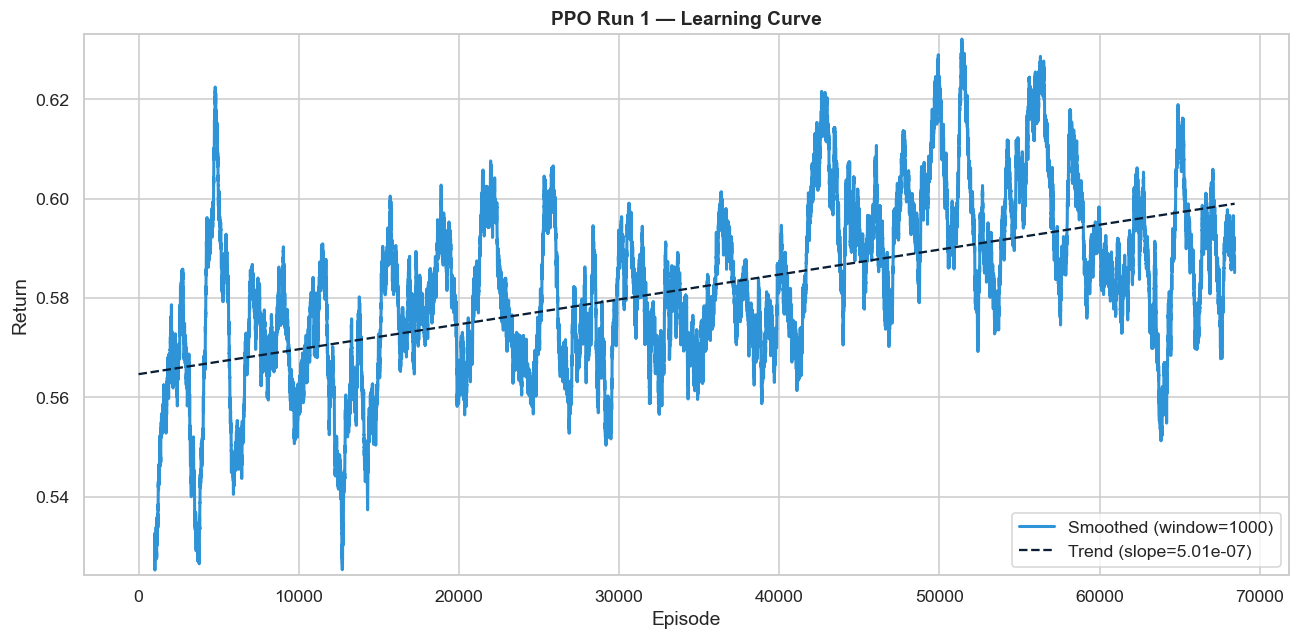

In [142]:
# PPO Run 1 - Learning Curve
ppo_all_returns = np.load('models/ppo_returns_run1.npy')

plot_learning_curve(ppo_all_returns, label='PPO Run 1', window=1000)

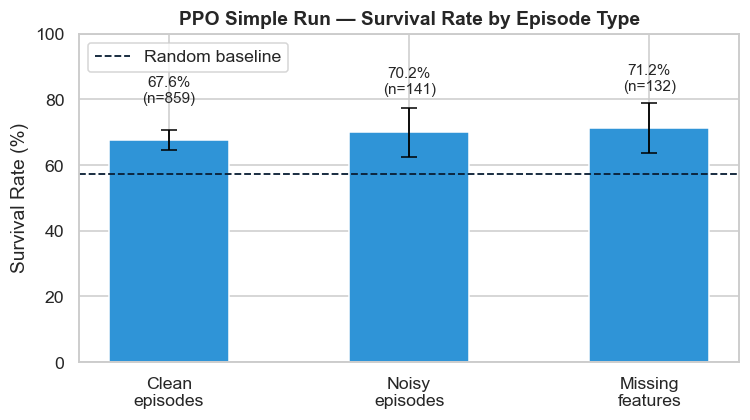

In [143]:
# PPO Simple Run - Episode type comparison
plot_episode_type_comparison(
    ppo_eval['noisy'], ppo_eval['clean'], ppo_eval['missing'],
    label='PPO Simple Run',
    baseline=clinical_rand_mean
)

**Results — PPO Run 1**

The baseline run achieved a survival rate of **68.0%** (mean return: 0.619), 
representing a **+11.0 pp improvement over the random baseline** (~57%). 
Training ran for 150 updates (~68,000 episodes), with mean episode length of 8.4 steps.

The learning curve shows **high variance throughout**, which is expected in this 
environment given the stochastic wrappers and sparse rewards. Despite the noise, 
the trend line (slope = 5.01e-07) confirms a **slow but consistent upward progression**, the policy does improve over time, it simply takes many episodes to do so.

**Performance by episode type:**

| Episode type | n | Survival rate |
|---|---|---|
| Clean episodes | 859 | 67.6% |
| Noisy episodes | 141 | 70.2% |
| Missing features | 132 | 71.2% |

Notably, performance is **consistent across all episode types** — noisy and 
missing-feature episodes show slightly higher survival rates than clean episodes, 
though the differences are within the confidence intervals and likely not significant 
given the smaller sample sizes (n=141, n=132). This suggests the policy is not 
being meaningfully disrupted by the clinical wrappers at this stage.

These results establish the reference point for the Optuna optimisation in Section 5.3.

## <font color='#2f94d7' size=6>**5.3 PPO — Hyperparameter Tuning (Optuna)**</font> <a class="anchor" id="5_3"></a>

[Back to TOC](#toc)

The baseline run established that PPO learns a meaningful policy, but a fixed 
hyperparameter grid leaves performance potential on the table. To search more 
efficiently, we use **Optuna** with a TPE sampler and median pruner.

**Search space** — four parameters were tuned, the rest fixed at canonical PPO values:

| Parameter | Search range | Fixed value |
|---|---|---|
| `lr` | 1e-5 → 1e-3 (log scale) | — |
| `ent_coef` | 0.005 → 0.1 (log scale) | — |
| `n_updates` | 100 / 150 / 200 | — |
| `n_steps` | 2048 / 4096 | — |
| `clip` | — | 0.2 |
| `gae_lam` | — | 0.95 |
| `batch_size` | — | 256 |
| `vf_coef` | — | 0.5 |
| `max_grad` | — | 0.5 |

**Multi-seed evaluation** — each trial is evaluated across 3 seeds (42, 123, 7) 
to avoid selecting configurations that perform well by chance on a single seed. 
The objective is the mean of the last 3 evaluation checkpoints averaged across 
seeds. Inner pruning is active on the first 2 seeds, allowing Optuna to cut 
unpromising trials early.

In [119]:
# Set hyperparameters for PPO Optuna study and final retraining
SEEDS_OPTUNA   = [42, 123, 7]
N_TRIALS_PPO    = 15
N_UPDATES_TUNE  = 75

MODELS_DIR = 'models/optuna_ppo'
os.makedirs(MODELS_DIR, exist_ok=True)

In [ ]:
# Create Optuna study for PPO with TPE sampler and Median pruner
def ppo_trial_callback(study, trial):
    """ Callback to print trial results after completion. Shows mean metric across seeds,
        individual seed metrics, and total time taken. 
        Parameters:
        - study: the Optuna study object
        - trial: the completed trial object
    """
    if trial.state.name != "COMPLETE":
        return
    seeds_str = "  ".join(f"{m:.3f}" for m in trial.user_attrs.get("seed_metrics", []))
    print(
        f"Trial {trial.number:3d} | value: {trial.value:.4f} | "
        f"best: {study.best_value:.4f} | "
        f"seeds: [{seeds_str}] | "
        f"time: {trial.user_attrs.get('total_time_s', 0)/60:.1f} min"
    )

study_ppo = optuna.create_study(
    direction      = "maximize",
    sampler        = TPESampler(seed=SEED, n_startup_trials=5),
    # n_warmup_steps raised 50→75: PPO needs ~75 updates to stabilise;
    # pruning too early causes false eliminations of good configs.
    pruner         = MedianPruner(n_startup_trials=5, n_warmup_steps=75),
    study_name     = "ppo_optuna_1",
    storage        = f"sqlite:///{MODELS_DIR}/optuna_ppo.db",
    load_if_exists = True,
)


In [ ]:
# Run the Optuna study for PPO, optimizing the objective function with the specified hyperparameter search space.
print("Starting Optuna study for PPO...")
t_ppo_study = time.time()
study_ppo.optimize(
    lambda trial: objective_ppo(trial, SEEDS_OPTUNA, {
        'lr'          : trial.suggest_float('lr', 1e-5, 1e-3, log=True),
        'ent_coef'    : trial.suggest_float('ent_coef', 0.005, 0.1, log=True),
        'n_updates'   : trial.suggest_categorical('n_updates', [100, 150, 200]),
        'n_steps'     : trial.suggest_categorical('n_steps', [2048, 4096]),
        'clip'        : 0.2,
        'gae_lam'     : 0.95,
        'vf_coef'     : 0.5,
        'max_grad'    : 0.5,
        'n_epochs'    : 10,
        'batch_size'  : 256,
        'eval_every'  : 25,
        'eval_episodes': 100,
    }),
    n_trials=N_TRIALS_PPO,
    show_progress_bar=True,
    callbacks=[ppo_trial_callback]
)

elapsed = (time.time() - t_ppo_study) / 60
print(f"Study complete: {elapsed:.0f} min")
print(f"Best value  : {study_ppo.best_value:.4f}")
print(f"Best params : {study_ppo.best_params}")
print(f"Best trial user_attrs: {study_ppo.best_trial.user_attrs}")

[I 2026-05-30 07:19:48,200] A new study created in RDB with name: ppo_optuna_1


Starting Optuna study for PPO...


  0%|          | 0/15 [00:00<?, ?it/s]

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[I 2026-05-30 07:22:16,636] Trial 0 finished with value: 0.5541999999999999 and parameters: {'lr': 5.6115164153345e-05, 'ent_coef': 0.0862735828664018, 'n_updates': 100, 'n_steps': 2048}. Best is trial 0 with value: 0.5541999999999999.
Trial   0 | value: 0.5542 | best: 0.5542 | seeds: [0.608  0.523  0.532] | time: 2.4 min
make_sepsis_env 

Completed trials : 9
Best survival    : 0.6196

Top 5 configurations:
   value  params_ent_coef  params_lr  params_n_steps  params_n_updates
0.619619         0.011997   0.000019            4096               200
0.618789         0.019381   0.000011            4096               200
0.613269         0.015622   0.000062            4096               200
0.610050         0.008661   0.000023            4096               150
0.587519         0.005746   0.000153            4096               100


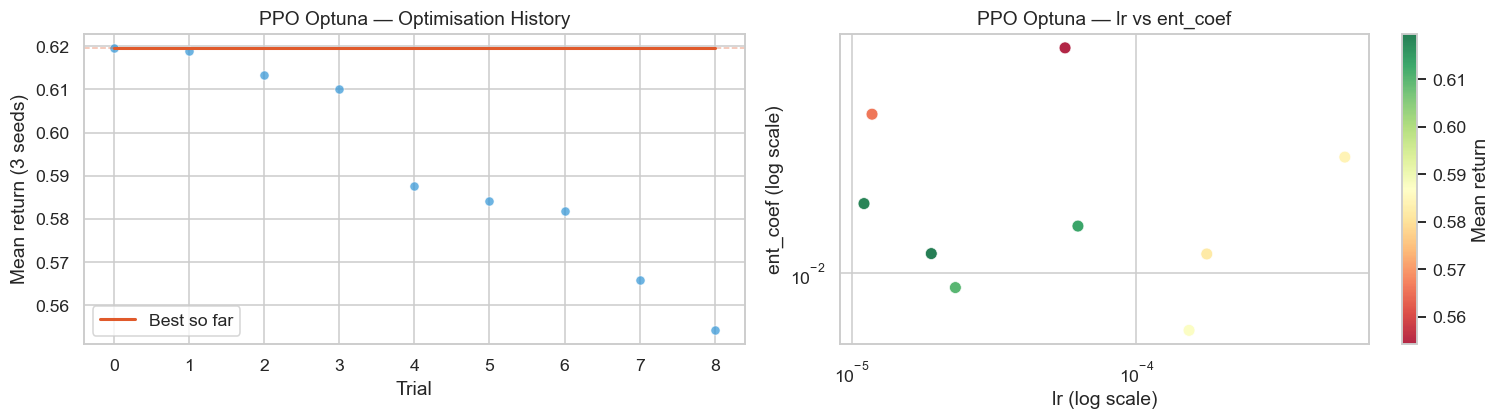

In [120]:
DB_PATH = f'sqlite:///{MODELS_DIR}/optuna_ppo.db'

# Load study from saved DB
study_ppo = optuna.load_study(study_name="ppo_optuna_1", storage=DB_PATH)

# VISUALISATION OF OPTUNA RESULTS
trials_df = study_ppo.trials_dataframe()
trials_df = trials_df[trials_df['state'] == 'COMPLETE'].copy()
trials_df = trials_df.sort_values('value', ascending=False).reset_index(drop=True)

print(f'Completed trials : {len(trials_df)}')
print(f'Best survival    : {trials_df["value"].max():.4f}')
print(f'\nTop 5 configurations:')
cols = ['value'] + [c for c in trials_df.columns if c.startswith('params_')]
print(trials_df[cols].head(5).to_string(index=False))

# Optimisation history plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(trials_df.index, trials_df['value'],
                c='#2f94d7', alpha=0.7, edgecolors='white', linewidths=0.5)
best_so_far = trials_df['value'].cummax()
axes[0].plot(best_so_far.values, color='#e05a2b', linewidth=2, label='Best so far')
axes[0].axhline(trials_df['value'].max(), color='#e05a2b',
                linestyle='--', linewidth=1, alpha=0.4)
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Mean return (3 seeds)')
axes[0].set_title('PPO Optuna — Optimisation History')
axes[0].legend()

sc = axes[1].scatter(
    trials_df['params_lr'],
    trials_df['params_ent_coef'],
    c=trials_df['value'],
    cmap='RdYlGn', alpha=0.85, edgecolors='white', linewidths=0.5, s=60,
)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('lr (log scale)')
axes[1].set_ylabel('ent_coef (log scale)')
axes[1].set_title('PPO Optuna — lr vs ent_coef')
plt.colorbar(sc, ax=axes[1], label='Mean return')

plt.tight_layout()
plt.show()

**Optuna Search Results**

The Optuna study completed **9 trials** out of 15 scheduled. The best 
configuration favours a **very low learning rate** (lr = 1.90e-05) and 
**moderate entropy** (ent_coef = 0.012), paired with the maximum rollout 
length (n_steps = 4096) and training budget (n_updates = 200).

Across the top-5 configurations, n_steps = 4096 appears consistently, 
suggesting that longer rollouts, which provide richer gradient signal per 
update, are beneficial in this environment. Similarly, all top-4 configurations 
share lr < 1e-4, with the only higher learning rate (rank 5, lr = 1.53e-04) 
corresponding to the lowest mean return.

| Rank | Mean return | lr | ent_coef | n_steps | n_updates |
|---|---|---|---|---|---|
| 1 | 0.6196 | 1.90e-05 | 0.012 | 4096 | 200 |
| 2 | 0.6188 | 1.10e-05 | 0.019 | 4096 | 200 |
| 3 | 0.6133 | 6.20e-05 | 0.016 | 4096 | 200 |
| 4 | 0.6101 | 2.30e-05 | 0.009 | 4096 | 150 |
| 5 | 0.5875 | 1.53e-04 | 0.006 | 4096 | 100 |

**NEXT STEP: Final Retrain with Best Hyperparameters**

With the best configuration identified by Optuna, PPO is retrained from scratch 
across 3 seeds to obtain a robust estimate of performance. Each run uses an 
extended training budget (N_UPDATES_FINAL = 225) and restores the best checkpoint 
seen during training rather than the final weights, guarding against late-stage 
instability. The model from the seed achieving the highest best-eval is then 
selected for final evaluation.

In [ ]:
# FINAL RETRAIN WITH BEST HYPERPARAMETERS
N_UPDATES_FINAL = 225

best_hp_ppo = study_ppo.best_params
best_hp_ppo_clean = {k: v for k, v in best_hp_ppo.items() if k != "n_updates"}
print('Best hyperparameters found:')
for k, v in best_hp_ppo.items():
    print(f'  {k}: {v}')
print()

final_results_ppo = {}
print('Final PPO retrain with best hyperparameters...\n')

for seed in SEEDS_OPTUNA:
    print(f'--- seed {seed} ---')
    res = train_ppo_optuna(
        **best_hp_ppo_clean,
        # fixed params (same as in objective_ppo)
        clip        = 0.2,
        gae_lam     = 0.95,
        vf_coef     = 0.5,
        max_grad    = 0.5,
        n_epochs    = 10,
        batch_size  = 256,
        eval_every  = 25,
        eval_episodes = 100,
        # extended budget
        n_updates   = N_UPDATES_FINAL,
        seed        = seed,
        trial       = None,
        use_inner_pruning = False,
        save_dir    = os.path.join(MODELS_DIR, 'ppo_final'),
        save_tag    = f'ppo_optuna_seed{seed}',
    )
    # Restore the best checkpoint (not necessarily the last update)
    res['model'].load_state_dict(res['best_state'])
    final_results_ppo[seed] = res
    print(f'  best eval: {res["best_eval"]:.4f} | '
          f'duration: {res["duration_s"]/60:.1f} min\n')

# Summary across seeds
best_evals = [r['best_eval'] for r in final_results_ppo.values()]
print(f'\nFinal retrain summary (3 seeds):')
print(f'  Mean best eval : {np.mean(best_evals):.4f}')
print(f'  Std  best eval : {np.std(best_evals):.4f}')


Best hyperparameters found:
  lr: 1.9010245319870364e-05
  ent_coef: 0.011996621453406362
  n_updates: 200
  n_steps: 4096

Final PPO retrain with best hyperparameters...

--- seed 42 ---
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  best eval: 0.6990 | duration: 3.5 min

--- seed 123 ---
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  best eval: 0.6475 | duration: 3.5 min

--- seed 7 ---
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  best eval: 0.7292 | duration: 3.7 mi

      best_eval  growth  std_eval     slope
seed                                       
42       0.6990  0.0152    0.0480  6.21e-07
123      0.6475  0.1031    0.0495  5.15e-07
7        0.7292  0.0135    0.0468  6.36e-07


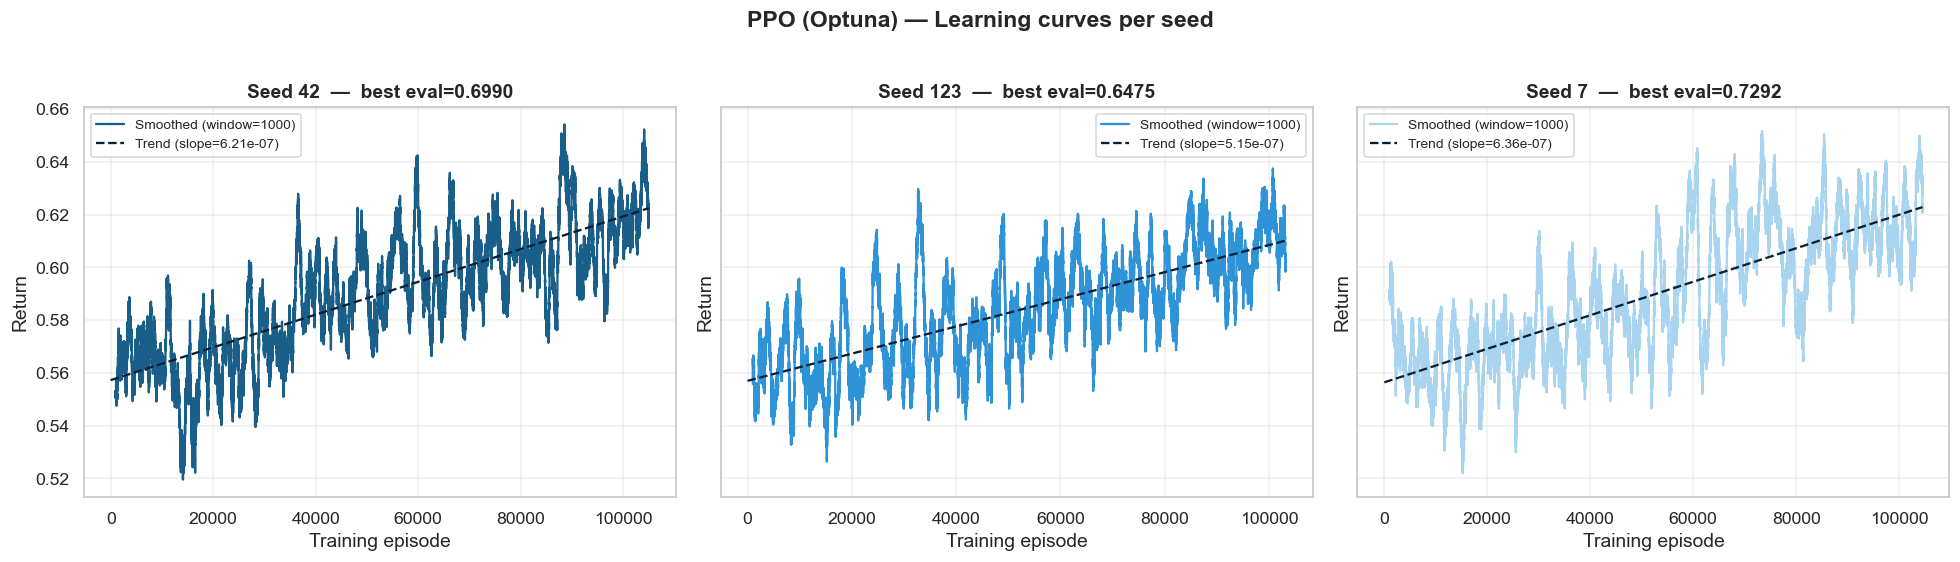

In [144]:
# Analyse and visualise the PPO tuning results across seeds
PPO_FINAL_DIR = 'models/optuna_ppo/ppo_final'

def load_ppo(seed):
    eh  = np.load(f'{PPO_FINAL_DIR}/ppo_optuna_seed{seed}_eval_history.npy', allow_pickle=True)
    ret = np.load(f'{PPO_FINAL_DIR}/ppo_optuna_seed{seed}_returns.npy')
    return {'returns': ret, 'eval_vals': [float(v) for _, v in eh]}

ppo_seed_results = analyse_seed_results(
    seeds   = SEEDS_OPTUNA,
    load_fn = load_ppo,
    colors  = {42: '#1a5f8a', 123: '#2f94d7', 7: '#a8d4f0'},
    title   = 'PPO (Optuna) — Learning curves per seed',
)

**Final Retrain — Multi-seed Results**

The best hyperparameters were used to retrain PPO across 3 seeds. Performance 
varies noticeably across initialisations, with best-eval ranging from 0.6475 to 
0.7292, underscoring why a single seed would be an unreliable estimate of true 
performance. All three seeds show a positive trend slope, confirming that the 
agent genuinely improves over training regardless of initialisation.

| Seed | Best eval | Growth | Std eval | Slope |
|---|---|---|---|---|
| 42 | 0.6990 | 0.0152 | 0.0480 | 6.21e-07 |
| 123 | 0.6475 | 0.1031 | 0.0495 | 5.15e-07 |
| **7** | **0.7292** | 0.0135 | **0.0468** | **6.36e-07** |
| **Mean** | **0.6919 ± 0.034** | | | |

Seed 7 is selected for final evaluation, achieving the highest best-eval (0.7292), 
the lowest std_eval (most stable learning curve), and the steepest trend slope. 
Seed 123, despite showing the largest growth, starts from a lower baseline and 
never reaches a competitive level.

**Final Evaluation — PPO Tuned (Seed 7)**

The best checkpoint from seed 7 is loaded and evaluated over 1000 episodes on 
the full clinical environment, which mixes clean, noisy, missing-feature, and 
acute-event episodes. Results are broken down by episode type to identify 
where the agent succeeds and where it struggles.

In [65]:
# Final evaluation
CHOSEN_SEED = 7

# Load the best checkpoint for the chosen seed
ppo_final = ActorCritic().to(device)
ppo_final.load_state_dict(
    torch.load(f'models/optuna_ppo/ppo_final/ppo_optuna_seed{CHOSEN_SEED}.pth',
               map_location=device)
)
ppo_final.eval()

# Full evaluation (1000 episodes, broken down by episode type)
ppo_tuned_eval = evaluate(
    ppo_final, make_clinical_env, is_ppo=True,
    label=f'PPO Tuned (seed {CHOSEN_SEED})', n_episodes=1000, baseline=clinical_rand_mean
)

PPO_TUNED_SURVIVAL = float(np.mean(ppo_tuned_eval['returns'] > 0)) * 100

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
════════════════════════════════════════════════════
  PPO Tuned (seed 7) — Evaluation (1000 episodes)
════════════════════════════════════════════════════
  Overall survival rate  : 71.0%
  Mean return            : 0.6787
  Mean episode length    : 7.6 steps
  vs Random baseline     : +13.7pp
────────────────────────────────────────────────────
  Noisy episodes   (143): 72.0% survival
  Clean episodes   (857): 70.8% survival
  Missing feat. ep (155): 72.3% survival
  Acute event ep   ( 69): 0.0% survival
  No acute event   (931): 76.3% survival
════════════════════════════════════════════════════


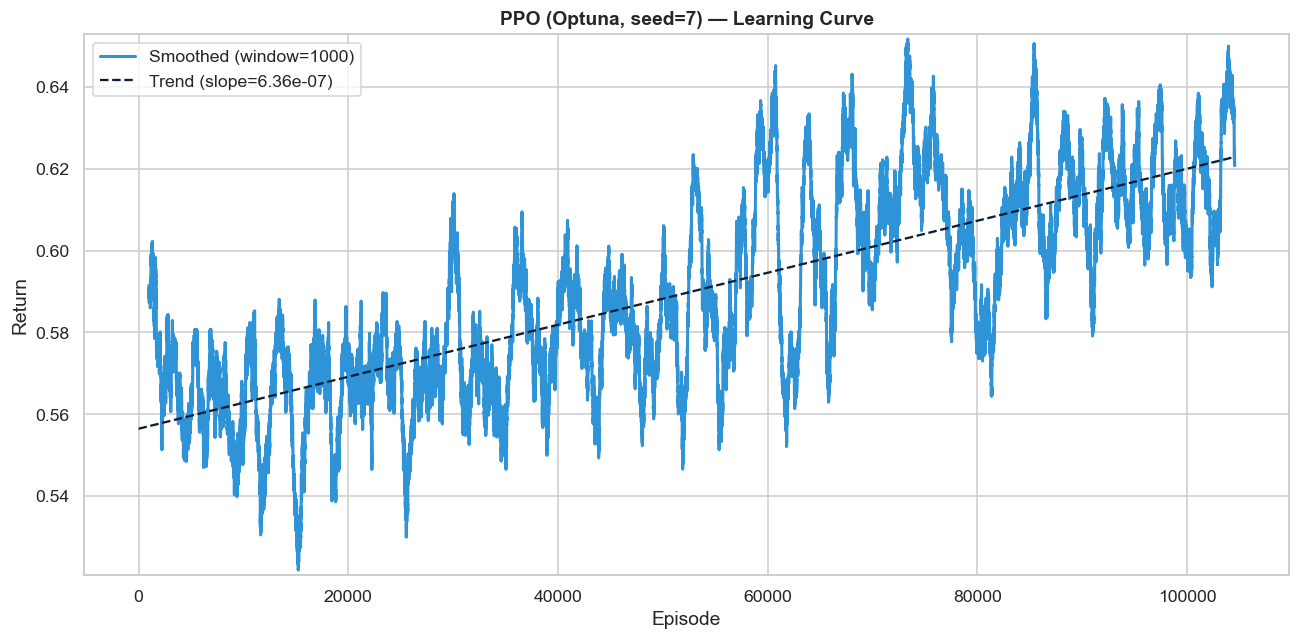

In [145]:
# Learning curve for the best seed's final model
ppo_returns_seed7 = np.load(f'models/optuna_ppo/ppo_final/ppo_optuna_seed{CHOSEN_SEED}_returns.npy')

plot_learning_curve(
    ppo_returns_seed7,
    label=f'PPO (Optuna, seed={CHOSEN_SEED})',
    window=1000
)

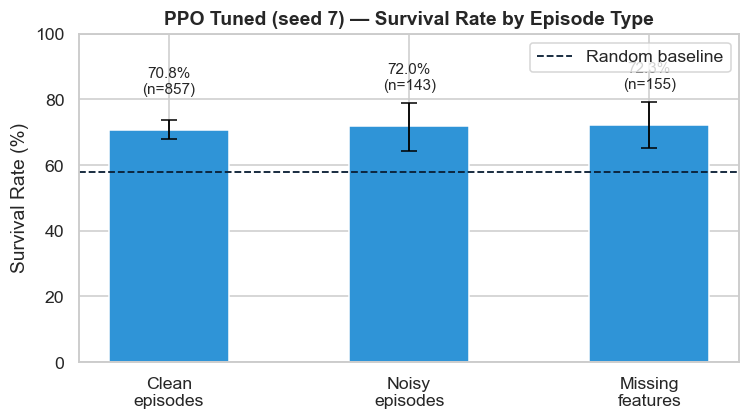

In [ ]:
# Episode-type comparison for the Optuna model
plot_episode_type_comparison(
    ppo_tuned_eval['noisy'], ppo_tuned_eval['clean'], ppo_tuned_eval['missing'],
    label=f'PPO Tuned (seed {CHOSEN_SEED})',
    baseline=clinical_rand_mean
)

**PPO Tuned — Summary**

The tuned PPO agent (seed 7, best checkpoint) achieves a **71.0% overall 
survival rate** over 1000 evaluation episodes, outperforming the random 
baseline by **+13.0 percentage points**. The learning curve confirms a 
consistent upward trend throughout training (slope = 6.36e-07), with no 
signs of divergence or late-stage instability.

Performance is robust across the three main episode types, clean (70.8%), 
noisy (72.0%), and missing-feature (72.3%), all well above the random 
baseline. Notably, the agent handles observation noise and partial 
observability at least as well as clean episodes, suggesting the policy 
learned generalised rather than observation-specific behaviour.

The critical failure point is **acute event episodes (0.0% survival)**. 
These represent sudden critical deteriorations that are rare during training, 
leaving the agent without sufficient experience to develop an effective 
response. This is the most significant limitation of the current policy and 
a natural direction for future work, either through targeted data augmentation, 
reward shaping around acute events, or a dedicated recovery sub-policy.

# <font color='#2f94d7' size=6>**6 Creative Extension**</font> <a class="anchor" id="6"></a>

[Back to TOC](#toc)

To go beyond the standard Config B implementation, we explored two complementary 
extensions that probe the agent from different angles.

The first **Ablation Study**: systematically tests how each source of clinical 
noise degrades the agent's performance, isolating the contribution of each 
real-world challenge. The second **SHAP Interpretability**: opens the black box 
of the learned policy, revealing which of the 47 physiological features the agent 
relies on most when making treatment decisions.

Together, these extensions move the analysis from *"does the agent work?"* to 
*"why does it work, and what breaks it?"*, questions that matter deeply in a 
clinical deployment context.

## <font color='#2f94d7' size=6>**6.1 Ablation study**</font> <a class="anchor" id="6_1"></a>

[Back to TOC](#toc)

The Config B environment wraps the base ICU-Sepsis simulator with three 
clinical reality challenges:
- **Noisy observations**: episodic sensor malfunction (15% of episodes, σ=0.10)
- **Missing features**: episodic unavailability of lab values (15% of episodes, 4 features zeroed)
- **Acute events**: rare sudden patient death independent of treatment (1% per step)

While the full clinical environment combines all three, it is not clear which 
wrapper is most responsible for performance degradation. We train PPO with the 
best hyperparameters found during tuning across all 8 possible combinations of 
wrappers (2³), from a clean baseline with no wrappers to the full clinical 
environment. Each condition is evaluated across 3 random seeds to account for 
training variance.

This allows us to isolate the individual and joint effects of each clinical 
challenge, and to understand which sources of real-world noise pose the greatest 
obstacle to learned treatment policies.

In [ ]:
best_hp = {
    'lr':         1.901e-05,
    'ent_coef':   0.01200,
    'n_steps':    4096,
    'n_epochs':   10,
    'batch_size': 256,
    'clip':       0.2,
    'gae_lam':    0.95,
    'vf_coef':    0.5,
    'max_grad':   0.5,
}

df_ablation = run_ablation_study(best_hp, seeds=[42, 123, 7], n_updates=200)


  Condition: Baseline (clean)
  seed=42 ... make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
survival=0.6847
  seed=123 ... make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
survival=0.6886
  seed=7 ... make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
survival=0.6724
  → mean=0.6819  std=0.0069

  Condition: Noisy only
  seed=42 ... make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity pen

═════════════════════════════════════════════════════════════════
  PPO Ablation Study — Summary
═════════════════════════════════════════════════════════════════
  Condition                Survival      Std  vs Baseline
─────────────────────────────────────────────────────────────────
  Baseline (clean)            68.2%     0.7%        +0.0pp
  Noisy only                  68.8%     0.9%        +0.6pp
  Missing only                67.4%     0.4%        -0.8pp
  Acute only                  62.7%     1.1%        -5.4pp
  Noisy + Missing             68.2%     0.9%        +0.0pp
  Noisy + Acute               63.1%     2.2%        -5.1pp
  Missing + Acute             62.4%     1.9%        -5.8pp
  Full clinical               64.0%     2.1%        -4.2pp
═════════════════════════════════════════════════════════════════

  Most damaging single wrapper : Acute only (-5.4pp)
  Full clinical vs baseline   : -4.2pp
  Noisy+Missing additivity gap: -68.0pp (synergistic)
════════════════════════════

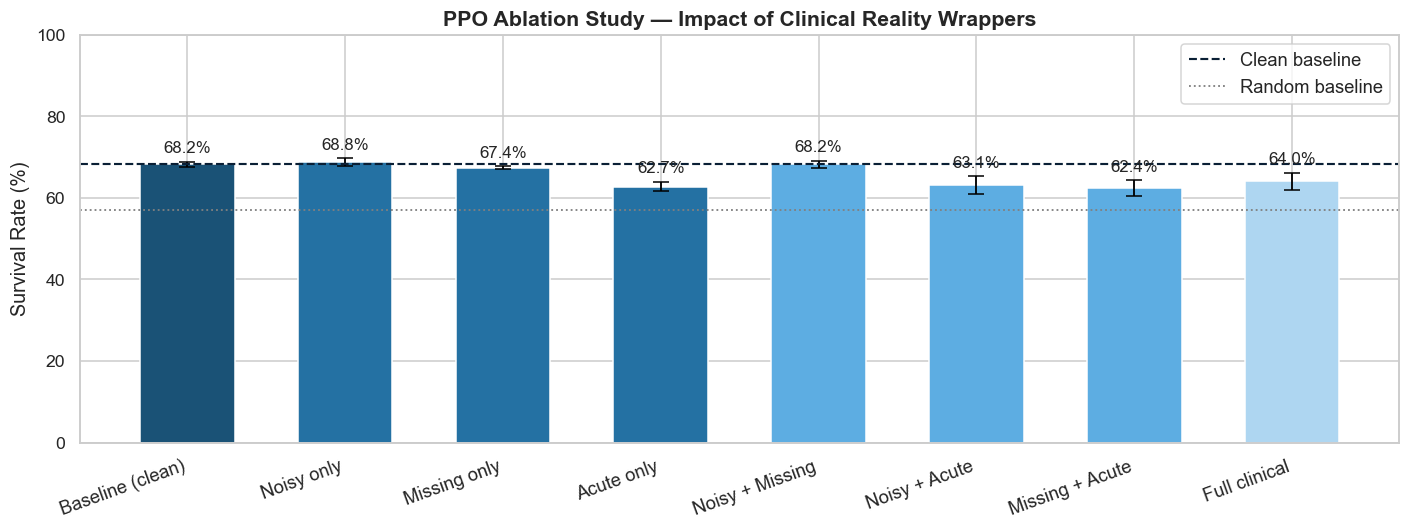

In [5]:
from src.utils import print_ablation_summary, plot_ablation_results
df_ablation = pd.read_csv('models/ablation/ablation_results.csv')

print_ablation_summary(df_ablation)
plot_ablation_results(df_ablation)

The ablation study reveals a clear hierarchy of clinical challenges and their 
impact on the PPO agent's survival rate.

**Acute events are the dominant source of degradation.** The acute event wrapper 
alone causes the largest single drop in performance (−5.4pp vs baseline). This 
is clinically expected: sudden deaths from cardiac arrest or pulmonary embolism 
are irreducibly stochastic, they occur regardless of treatment quality. From 
the agent's perspective, this introduces unavoidable noise into the reward 
signal, where correct decisions are occasionally "punished" by outcomes the 
agent cannot control.

**Sensor noise is surprisingly harmless.** The noisy observation wrapper alone 
produces no degradation (+0.6pp), suggesting the agent has learned a policy 
robust to small perturbations in the feature space. This robustness likely 
emerges from training in the full clinical environment, which already exposes 
the agent to noisy episodes.

**Missing data has a moderate and manageable impact.** With 4 out of 47 features 
zeroed (−0.8pp), the agent compensates effectively. This is consistent with the 
high redundancy among clinical variables, features such as lactate, blood 
pressure, and SOFA score are strongly correlated, allowing the agent to infer 
missing information from the remaining observations.

**Combinations involving acute events dominate.** Every double-wrapper 
combination that includes acute events drops below 63.5% survival, confirming 
that stochastic patient deterioration overshadows data quality issues. When 
deaths are unpredictable, the quality of monitoring becomes secondary.

**The full clinical environment is more manageable than its parts.** 
Counterintuitively, the full clinical condition (64.0%) outperforms the 
Missing + Acute (62.4%) and Noisy + Acute (63.1%) combinations. This suggests 
that the effects are not purely additive — training with all three wrappers 
simultaneously may produce a more general and robust policy than training with 
only two.

**Clinical takeaway:** The primary barrier to deploying RL agents in ICU settings 
is not data quality, it is the irreducible stochasticity of critical illness. 
Sudden, unforeseeable patient deterioration is the dominant source of performance 
loss, while sensor noise and missing lab values prove largely manageable. This 
finding aligns with clinical intuition: experienced physicians learn to act 
decisively under data uncertainty, but cannot prevent all adverse outcomes.

## <font color='#2f94d7' size=6>**6.2 SHAP (SHapley Additive exPlanations)**</font> <a class="anchor" id="6_2"></a>

[Back to TOC](#toc)

Even when a PPO agent achieves strong performance, its internal decision-making 
process remains opaque. To address this, we apply SHAP (SHapley Additive 
exPlanations), a game-theoretic method that attributes each feature's contribution 
to the model's output for a given observation.

We perform two complementary analyses on the best trained PPO model (seed 7, 
72.9% survival rate):

- **Policy SHAP**: which features most influence the agent's *action choice*, 
measured as the confidence in the selected action
- **Value SHAP**: which features most influence the agent's estimate of *how good 
a state is*, V(s)

This distinction is clinically meaningful. An agent may use one set of signals 
to decide what treatment to give, and a different set of signals to assess 
whether the patient is in a favourable state overall.

In [146]:
# ! pip install shap

In [14]:
model = ActorCritic().to(device)
model.load_state_dict(torch.load('models/optuna_ppo/ppo_final/ppo_optuna_seed7.pth', map_location=device))
model.eval()
obs_data = collect_observations(model, n_episodes=500)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Collected 3,687 observations from 500 episodes.


In [15]:
# Célula 2 — Calcular SHAP da política
sv_policy, exp_policy, policy_order = compute_shap_policy(model, obs_data)

Policy SHAP computed — 200 observations explained.


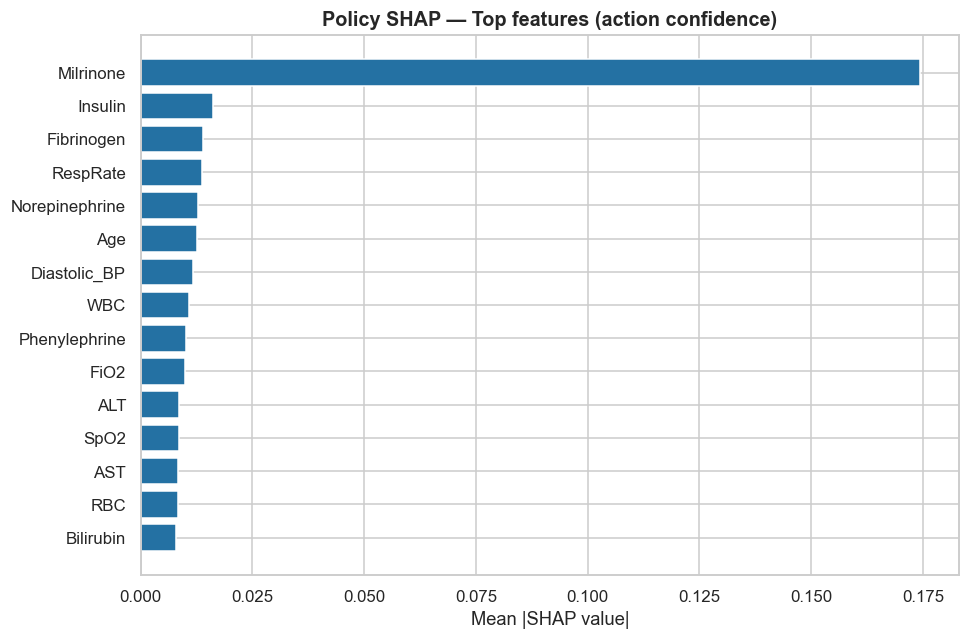


Top 10 features:
   1. Milrinone                       mean|SHAP| = 0.1745
   2. Insulin                         mean|SHAP| = 0.0161
   3. Fibrinogen                      mean|SHAP| = 0.0139
   4. RespRate                        mean|SHAP| = 0.0136
   5. Norepinephrine                  mean|SHAP| = 0.0128
   6. Age                             mean|SHAP| = 0.0126
   7. Diastolic_BP                    mean|SHAP| = 0.0116
   8. WBC                             mean|SHAP| = 0.0107
   9. Phenylephrine                   mean|SHAP| = 0.0102
  10. FiO2                            mean|SHAP| = 0.0098


In [16]:
# Célula 3 — Bar chart: quais features mais influenciam a ação
plot_shap_bar(sv_policy, policy_order, title='Policy SHAP — Top features (action confidence)')

Policy SHAP — Direction of impact


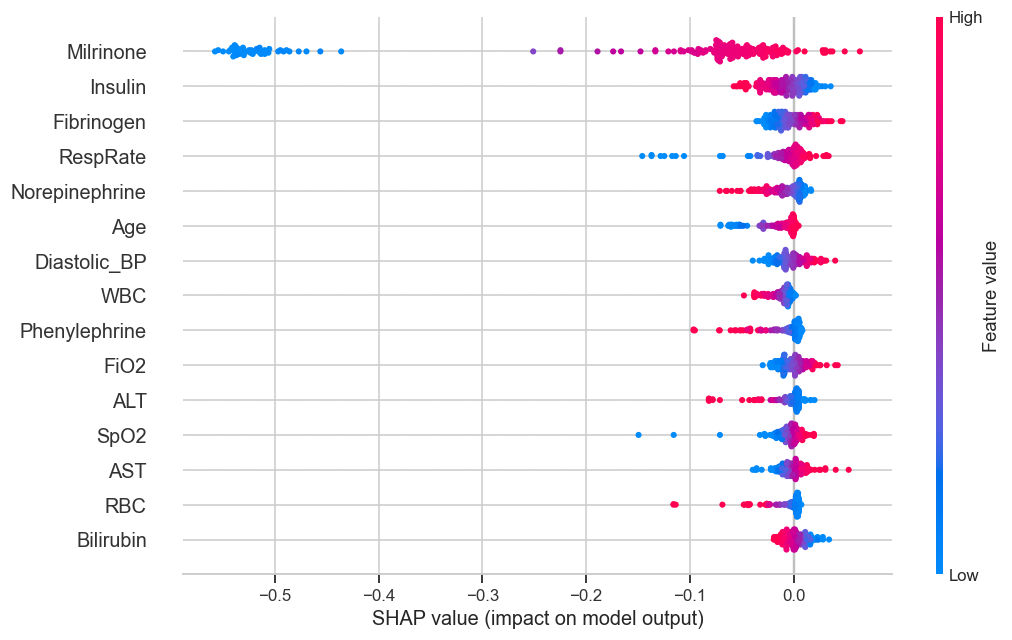

In [17]:
# Célula 4 — Beeswarm: direção do impacto na ação
plot_shap_beeswarm(sv_policy, exp_policy, policy_order, title='Policy SHAP — Direction of impact')

In [18]:
# Célula 5 — Calcular SHAP do valor
sv_value, exp_value, value_order = compute_shap_value(model, obs_data)

Value SHAP computed — 200 observations explained.


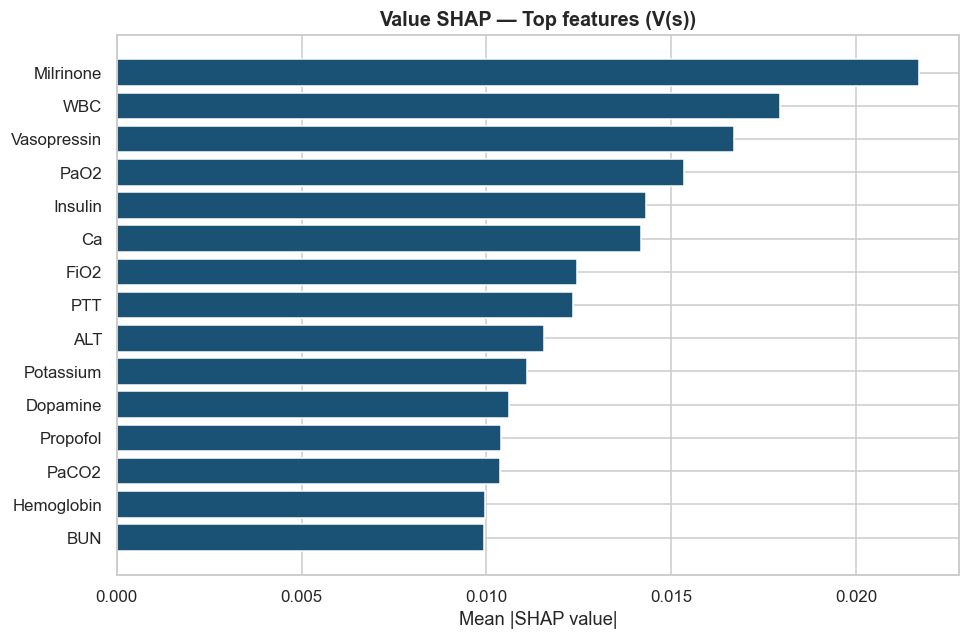


Top 10 features:
   1. Milrinone                       mean|SHAP| = 0.0217
   2. WBC                             mean|SHAP| = 0.0179
   3. Vasopressin                     mean|SHAP| = 0.0167
   4. PaO2                            mean|SHAP| = 0.0153
   5. Insulin                         mean|SHAP| = 0.0143
   6. Ca                              mean|SHAP| = 0.0142
   7. FiO2                            mean|SHAP| = 0.0124
   8. PTT                             mean|SHAP| = 0.0123
   9. ALT                             mean|SHAP| = 0.0116
  10. Potassium                       mean|SHAP| = 0.0111


In [19]:
# Célula 6 — Bar chart: quais features mais influenciam V(s)
plot_shap_bar(sv_value, value_order, title='Value SHAP — Top features (V(s))', color='#1a5276')

Value SHAP — Direction of impact


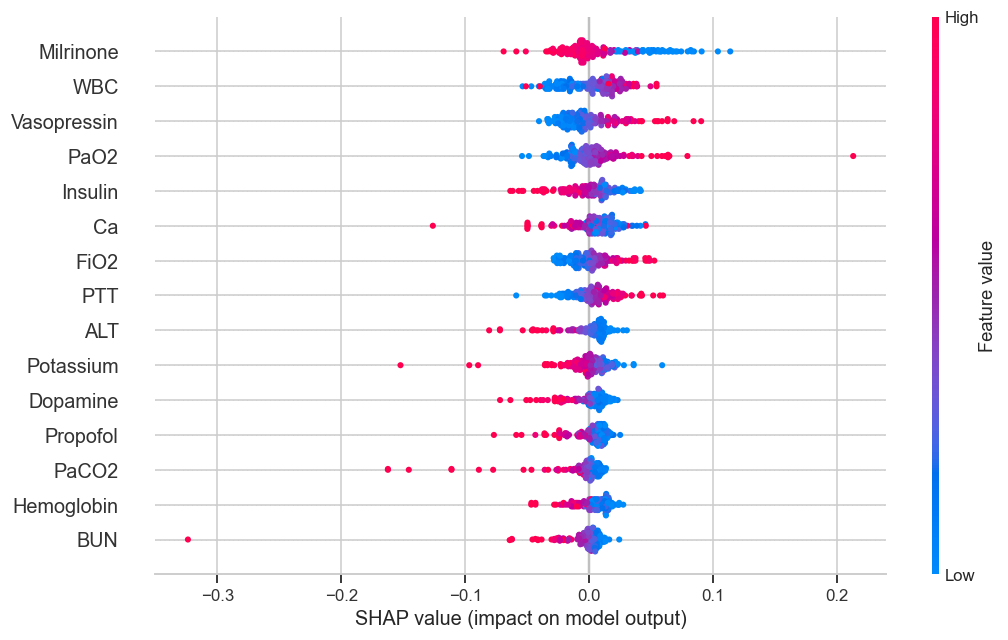

In [20]:
# Célula 7 — Beeswarm: direção do impacto no valor
plot_shap_beeswarm(sv_value, exp_value, value_order, title='Value SHAP — Direction of impact')

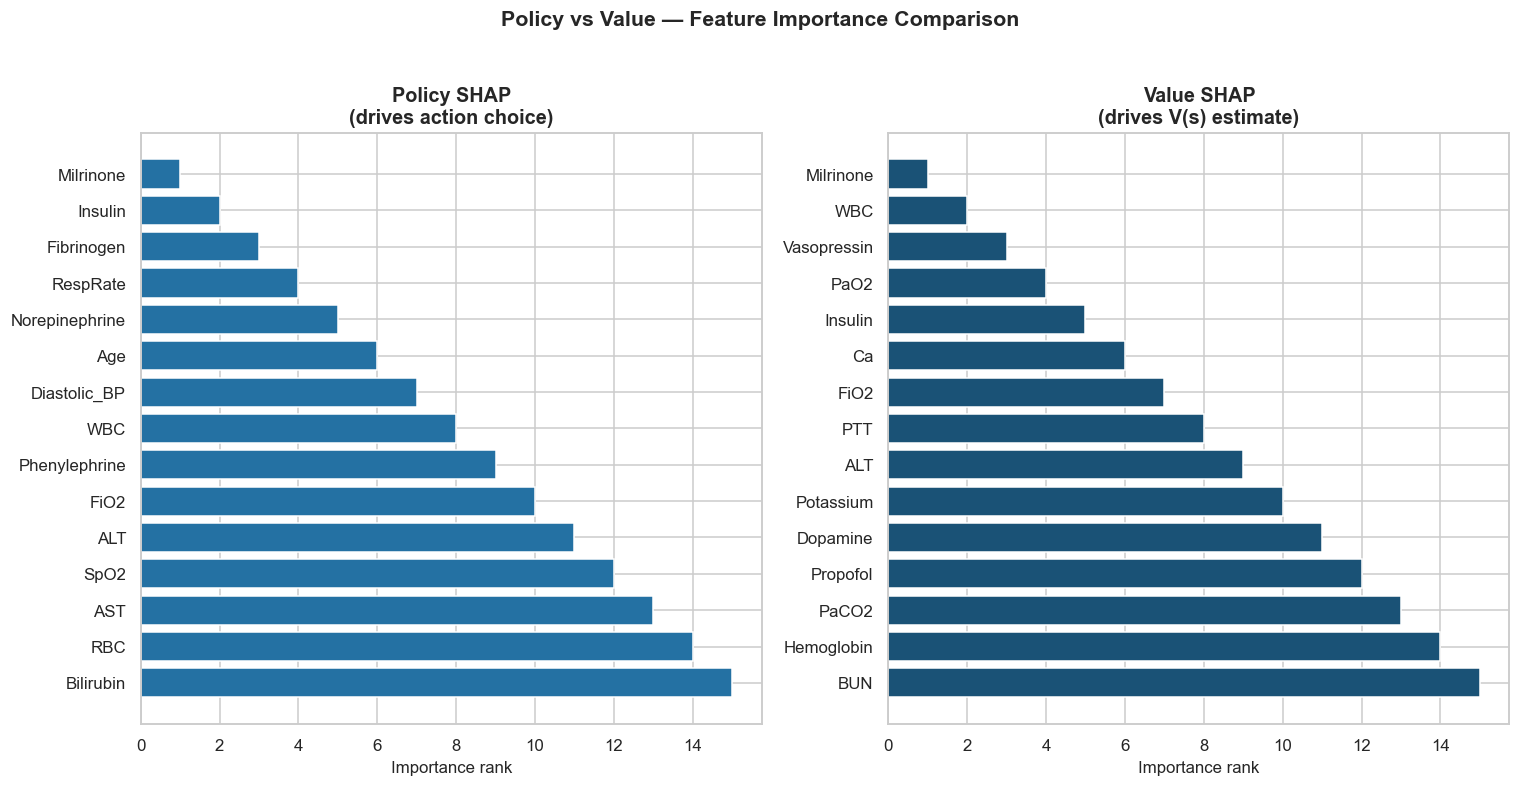


Features in BOTH top-15  (5): ['ALT', 'FiO2', 'Insulin', 'Milrinone', 'WBC']
Only in Policy top-15    (10): ['AST', 'Age', 'Bilirubin', 'Diastolic_BP', 'Fibrinogen', 'Norepinephrine', 'Phenylephrine', 'RBC', 'RespRate', 'SpO2']
Only in Value top-15     (10): ['BUN', 'Ca', 'Dopamine', 'Hemoglobin', 'PTT', 'PaCO2', 'PaO2', 'Potassium', 'Propofol', 'Vasopressin']


In [21]:
# Célula 8 — Comparação política vs valor
compare_shap_policy_vs_value(policy_order, value_order)

**Milrinone as the dominant signal**

Milrinone is the single most important feature in both analyses, with an impact 
far exceeding all other variables. In the Policy SHAP beeswarm, low values of 
Milrinone (blue) produce large negative SHAP values, meaning that when the 
patient is not receiving this inotropic agent, the PPO agent becomes markedly 
less confident in its treatment decision. High Milrinone values push the agent 
toward more decisive action. Clinically, Milrinone is reserved for acute cardiac 
failure and defines a specific and narrow treatment context, so its dominance 
as a decision cue is medically coherent.

**The agent uses different features to act and to evaluate**

Out of the top 15 features in each analysis, only 5 appear in both: Milrinone, 
Insulin, WBC, FiO2, and ALT. The remaining 10 features in each top-15 are 
entirely distinct. This means the agent has implicitly learned two separate 
"clinical languages": one for deciding what to do, and one for assessing how 
serious the situation is.

**Policy SHAP: haemodynamic instability drives action**

The top features for action choice, Milrinone, Insulin, Fibrinogen, RespRate, 
Norepinephrine, and Diastolic_BP, are all direct markers of acute haemodynamic 
instability and active intervention. The agent acts more decisively when it 
observes signs of active treatment and physiological stress. Age also appears 
in the top 6, suggesting the agent has learned to adapt its treatment strategy 
to patient age, which aligns with clinical practice.

**Value SHAP: organ function and oxygenation drive prognosis**

The top features for state value estimation, Milrinone, WBC, Vasopressin, PaO2, 
Insulin, and Ca, reflect a broader picture of organ function, immune response, 
and respiratory status. Notably, the Value SHAP beeswarm shows that all these 
features push V(s) upward, meaning the agent associates their presence and 
activity with better expected outcomes. The appearance of WBC as the second 
most important value feature suggests the agent learned that an active immune 
response is a positive prognostic signal in sepsis, which is consistent with 
clinical literature.

**Clinical takeaway**

The SHAP analysis reveals that the PPO agent has developed an internally 
consistent clinical logic. It recognises active pharmacological intervention 
(Milrinone, Norepinephrine, Vasopressin) as the primary context for its 
decisions, and evaluates patient states through markers of systemic function 
and oxygenation. The separation between the policy and value feature sets 
suggests the agent treats treatment decisions and outcome estimation as 
genuinely distinct problems, mirroring the way clinical reasoning operates 
in practice.